In [16]:
import pandas as pd
percorso_post = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/Reddit_Post_ChatGPT.csv'
df_post = pd.read_csv(percorso_post)
percorso_comment = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/Reddit_Comments_ChatGPT.csv'
df_comment = pd.read_csv(percorso_comment)

In [17]:
df_post

,search_topic,post_id,SubReddit,Title,Score,UpVote_Ratio,Num_Comments,created_utc
0,AGI e Sviluppo Tecnologico,1h8h483,Futurology,Murdered Insurance CEO Had Deployed an AI to A...,99503,0.90,3523,1.733534e+09
1,AGI e Sviluppo Tecnologico,1js17yn,Futurology,White House Accused of Using ChatGPT to Create...,36020,0.94,867,1.743852e+09
2,AGI e Sviluppo Tecnologico,1lmk3ih,Futurology,Bernie Sanders says that if AI makes us so pro...,34816,0.95,843,1.751108e+09
3,AGI e Sviluppo Tecnologico,1lxvkse,Futurology,Elon: “We tweaked Grok.” Grok: “Call me MechaH...,26039,0.92,957,1.752309e+09
4,AGI e Sviluppo Tecnologico,1mrqrt9,Futurology,AI experts return from China stunned: The U.S....,22905,0.91,1633,1.755338e+09
...,...,...,...,...,...,...,...,...
245,Etica e AI,1mg1x4t,Futurology,New Interactive Platform Brings AI Ethics Educ...,6,0.69,8,1.754170e+09
246,Etica e AI,1keyhgj,Futurology,Alternative Ownership Models for Humanoid Robots,7,0.77,5,1.746404e+09
247,Etica e AI,1nfud9l,Futurology,[D] AI Autonomy Creates 2029 Accountability Bill!,3,0.62,2,1.757760e+09
248,Etica e AI,1lbht0v,Futurology,Organizations Aren’t Ready for the Risks of Ag...,0,0.50,2,1.749932e+09


In [18]:
df_comment['body']

0        We get penalized for not having health insuran...
1        This whole thing feels like it's right out of ...
2        My favorite thing is the insurance companies c...
3        I 100% believe this, I have UHC as my provider...
4        I mean, this is what dissolution of the social...
                               ...                        
57882    In fairness to evolution, mere existence is a ...
57883    This would still be part of the transition per...
57884    That's true, but the difference is that this i...
57885    How? How is it getting to you? Who is coordina...
57886    Stay with me here; Government exists because i...
Name: body, Length: 57887, dtype: object

In [19]:
numero_duplicati_post = df_post['post_id'].duplicated().sum()

print(numero_duplicati_post)

41


In [20]:
df_post = df_post.drop_duplicates(subset='post_id')

# Thesis - Work on the Reddit merged Dataset

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
import spacy
from collections import Counter
from wordcloud import WordCloud
import nltk

In [22]:
df_merged = pd.merge(
    df_comment, 
    df_post, 
    on='post_id', 
    how='left',
    suffixes=('_comment', '_post')
)

print("\nDataFrame Unito (prime 5 righe):")
print(df_merged.head())


DataFrame Unito (prime 5 righe):
   post_id        search_topic_comment comment_id        author  \
0  1h8h483  AGI e Sviluppo Tecnologico    m0t34l9    mysteryiii   
1  1h8h483  AGI e Sviluppo Tecnologico    m0sx40t   kid_entropy   
2  1h8h483  AGI e Sviluppo Tecnologico    m0t5w7w       Syrairc   
3  1h8h483  AGI e Sviluppo Tecnologico    m0t7ung     austindsb   
4  1h8h483  AGI e Sviluppo Tecnologico    m0syjyw  XtremelyMeta   

                                                body  score  \
0  We get penalized for not having health insuran...   1582   
1  This whole thing feels like it's right out of ...   1456   
2  My favorite thing is the insurance companies c...   6743   
3  I 100% believe this, I have UHC as my provider...    180   
4  I mean, this is what dissolution of the social...  16727   

            search_topic_post   SubReddit  \
0  AGI e Sviluppo Tecnologico  Futurology   
1  AGI e Sviluppo Tecnologico  Futurology   
2  AGI e Sviluppo Tecnologico  Futurology   
3  A

In [23]:
"""""percorso_file = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/Reddit_Merged_ChatGPT.csv'
df_merged = pd.read_csv(percorso_file)"""

'""percorso_file = \'/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/Reddit_Merged_ChatGPT.csv\'\ndf_merged = pd.read_csv(percorso_file)'

In [24]:
print(df_merged.head(5))

   post_id        search_topic_comment comment_id        author  \
0  1h8h483  AGI e Sviluppo Tecnologico    m0t34l9    mysteryiii   
1  1h8h483  AGI e Sviluppo Tecnologico    m0sx40t   kid_entropy   
2  1h8h483  AGI e Sviluppo Tecnologico    m0t5w7w       Syrairc   
3  1h8h483  AGI e Sviluppo Tecnologico    m0t7ung     austindsb   
4  1h8h483  AGI e Sviluppo Tecnologico    m0syjyw  XtremelyMeta   

                                                body  score  \
0  We get penalized for not having health insuran...   1582   
1  This whole thing feels like it's right out of ...   1456   
2  My favorite thing is the insurance companies c...   6743   
3  I 100% believe this, I have UHC as my provider...    180   
4  I mean, this is what dissolution of the social...  16727   

            search_topic_post   SubReddit  \
0  AGI e Sviluppo Tecnologico  Futurology   
1  AGI e Sviluppo Tecnologico  Futurology   
2  AGI e Sviluppo Tecnologico  Futurology   
3  AGI e Sviluppo Tecnologico  Futurol

## EDA - Exploratory Data Analysis

In [25]:
print(df_merged.columns)

Index(['post_id', 'search_topic_comment', 'comment_id', 'author', 'body',
       'score', 'search_topic_post', 'SubReddit', 'Title', 'Score',
       'UpVote_Ratio', 'Num_Comments', 'created_utc'],
      dtype='object')


In [26]:
df_merged = df_merged.drop(['search_topic_post'], axis=1)

In [27]:
df_merged = df_merged.rename(columns={'search_topic_comment': 'search_topic', 'score': 'score_comment', 'Score': 'score_post'})

In [28]:
print(df_merged.columns)

Index(['post_id', 'search_topic', 'comment_id', 'author', 'body',
       'score_comment', 'SubReddit', 'Title', 'score_post', 'UpVote_Ratio',
       'Num_Comments', 'created_utc'],
      dtype='object')


In [29]:
df_merged['body_len'] = df_merged['body'].str.len()
df_merged['word_count'] = df_merged['body'].str.split().str.len()
df_merged['avg_word_count'] = df_merged['body_len'] / df_merged['word_count']

In [30]:
ids_to_remove = [
    "1keyhgj", "1k3f8q4", "1h3onlx", "1kspqmc", "1mhegmw", "1iqyy19", "1h69vuu",
    "1k536ei", "1hkwrh1", "1m6jhv6", "1kmputa", "1l5s4lg", "1jz39uz", "1hetvh7",
    "1hhisri", "1mxvwu2", "1kds8xx", "1n3zrgc", "1ltmp2c", "1m84efp", "1muksse",
    "1kmisjx", "1nlwi9i", "1jv3ga6", "1jr7l2a", "1hvthra", "1jfe66a", "1ncx1qm"
]

df_merged = df_merged[~df_merged['post_id'].isin(ids_to_remove)]


### General information

In [31]:
df_merged.shape

(52139, 15)

In [32]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52139 entries, 0 to 57886
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   post_id         52139 non-null  object 
 1   search_topic    52139 non-null  object 
 2   comment_id      52139 non-null  object 
 3   author          49088 non-null  object 
 4   body            52139 non-null  object 
 5   score_comment   52139 non-null  int64  
 6   SubReddit       52139 non-null  object 
 7   Title           52139 non-null  object 
 8   score_post      52139 non-null  int64  
 9   UpVote_Ratio    52139 non-null  float64
 10  Num_Comments    52139 non-null  int64  
 11  created_utc     52139 non-null  float64
 12  body_len        52139 non-null  int64  
 13  word_count      52139 non-null  int64  
 14  avg_word_count  52139 non-null  float64
dtypes: float64(3), int64(5), object(7)
memory usage: 6.4+ MB


In [33]:
df_merged.describe()

,score_comment,score_post,UpVote_Ratio,Num_Comments,created_utc,body_len,word_count,avg_word_count
count,52139.000000,52139.000000,52139.000000,52139.000000,5.213900e+04,52139.000000,52139.000000,52139.000000
mean,27.765070,8525.411419,0.922532,742.104509,1.747446e+09,275.625386,48.002186,5.926071
std,234.506867,11095.346412,0.059226,593.217671,8.058412e+06,358.271271,60.460090,4.750685
min,-263.000000,0.000000,0.500000,2.000000,1.729438e+09,5.000000,1.000000,2.071429
25%,1.000000,1848.000000,0.900000,299.000000,1.739613e+09,85.000000,15.000000,5.285714
50%,2.000000,7389.000000,0.940000,637.000000,1.748714e+09,164.000000,29.000000,5.617021
75%,8.000000,11711.000000,0.960000,977.000000,1.754214e+09,324.000000,57.000000,6.000000
max,16727.000000,99503.000000,0.990000,3523.000000,1.760275e+09,7579.000000,1327.000000,398.000000


In [34]:
df_merged.groupby('search_topic').size()
# Biggest problem, "impatto sul lavoro", "regolamentazione" and "sicurezza" 
# have more comments than "AGI e Sviluppo Tecnologico"

search_topic
AGI e Sviluppo Tecnologico    19255
Etica e AI                     3462
Impatto sul Lavoro e AI       15313
Regolamentazione e AI          7284
Sicurezza e AI                 6825
dtype: int64

In [35]:
stats = df_merged.groupby('search_topic').agg(
    n_commenti=('score_comment', 'size'),
    score_medio=('score_comment', 'mean'),
    score_mediano=('score_comment', 'median'),
    lunghezza_media=('body_len', 'mean'),
    lunghezza_mediana=('body_len', 'median')
).round(2)

print(stats)

                            n_commenti  score_medio  score_mediano  \
search_topic                                                         
AGI e Sviluppo Tecnologico       19255        40.51            3.0   
Etica e AI                        3462         6.40            1.0   
Impatto sul Lavoro e AI          15313        26.08            2.0   
Regolamentazione e AI             7284        18.64            2.0   
Sicurezza e AI                    6825        16.15            2.0   

                            lunghezza_media  lunghezza_mediana  
search_topic                                                    
AGI e Sviluppo Tecnologico           254.66              153.0  
Etica e AI                           339.85              195.0  
Impatto sul Lavoro e AI              285.56              176.0  
Regolamentazione e AI                276.88              163.0  
Sicurezza e AI                       278.57              162.0  


In [36]:
mappa_raggruppamento = {
    "AGI e Sviluppo Tecnologico": "AGI e Sviluppo Tecnologico",
    
    "Impatto sul Lavoro e AI": "Impatto Socio-Economico e Governance",
    "Regolamentazione e AI": "Impatto Socio-Economico e Governance",
    
    "Sicurezza e AI": "Rischi, Etica e Sicurezza",
    "Etica e AI": "Rischi, Etica e Sicurezza"
}

In [37]:
df_merged['macro_topic'] = df_merged['search_topic'].map(mappa_raggruppamento)

In [38]:
print("Distribuzione dopo il raggruppamento in 'macro_topic':")
print(df_merged['macro_topic'].value_counts())

Distribuzione dopo il raggruppamento in 'macro_topic':
macro_topic
Impatto Socio-Economico e Governance    22597
AGI e Sviluppo Tecnologico              19255
Rischi, Etica e Sicurezza               10287
Name: count, dtype: int64


In [39]:
stats = df_merged.groupby('macro_topic').agg(
    n_commenti=('score_comment', 'size'),
    score_medio=('score_comment', 'mean'),
    score_mediano=('score_comment', 'median'),
    lunghezza_media=('body_len', 'mean'),
    lunghezza_mediana=('body_len', 'median')
).round(2)

print(stats)

                                      n_commenti  score_medio  score_mediano  \
macro_topic                                                                    
AGI e Sviluppo Tecnologico                 19255        40.51            3.0   
Impatto Socio-Economico e Governance       22597        23.68            2.0   
Rischi, Etica e Sicurezza                  10287        12.87            2.0   

                                      lunghezza_media  lunghezza_mediana  
macro_topic                                                               
AGI e Sviluppo Tecnologico                     254.66              153.0  
Impatto Socio-Economico e Governance           282.76              172.0  
Rischi, Etica e Sicurezza                      299.19              172.0  


Possiamo dire che nel subreddit scelto nell'ultimo anno il tema sull'impatto lavorativo dell'AI è un tema più sentito?

### Type of information

In [40]:
df_merged.columns

Index(['post_id', 'search_topic', 'comment_id', 'author', 'body',
       'score_comment', 'SubReddit', 'Title', 'score_post', 'UpVote_Ratio',
       'Num_Comments', 'created_utc', 'body_len', 'word_count',
       'avg_word_count', 'macro_topic'],
      dtype='object')

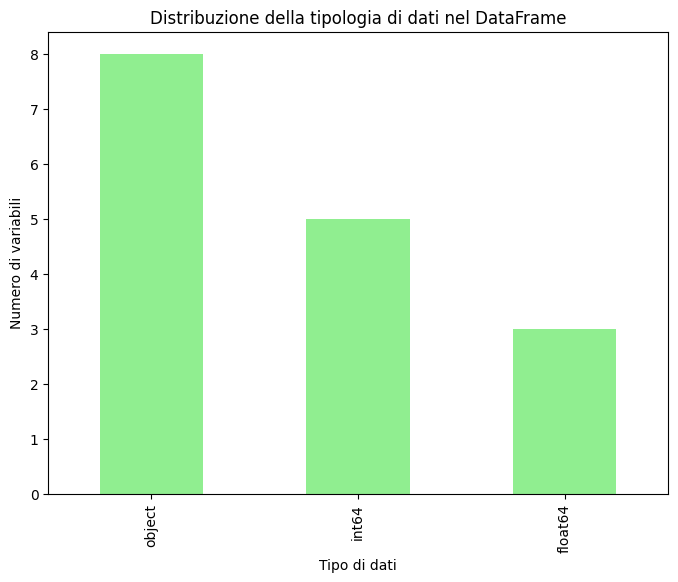

In [41]:
data_types = df_merged.dtypes
data_type_counts = data_types.value_counts()

plt.figure(figsize=(8, 6))
data_type_counts.plot(kind='bar', color='lightgreen')
plt.title('Distribuzione della tipologia di dati nel DataFrame')
plt.xlabel('Tipo di dati')
plt.ylabel('Numero di variabili')
plt.show()

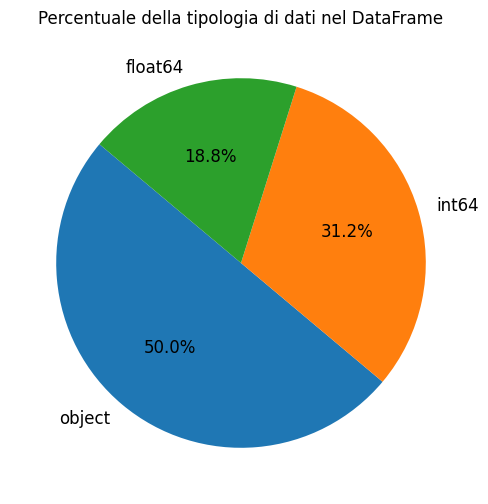

In [42]:
data_type_counts_percent = data_type_counts / data_type_counts.sum() * 100

plt.figure(figsize=(8, 6))
plt.pie(
    data_type_counts_percent,
    labels=data_type_counts.index,
    autopct='%.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)
plt.title('Percentuale della tipologia di dati nel DataFrame')
plt.show()

### Missing values

In [43]:
missing_values = df_merged.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

author    3051
dtype: int64


In [44]:
df_merged[df_merged['author'].isna()].groupby('search_topic').size()

search_topic
AGI e Sviluppo Tecnologico    1254
Etica e AI                     180
Impatto sul Lavoro e AI        753
Regolamentazione e AI          437
Sicurezza e AI                 427
dtype: int64

In [45]:
df_merged[df_merged['author'].isna()].groupby('macro_topic').size() 

macro_topic
AGI e Sviluppo Tecnologico              1254
Impatto Socio-Economico e Governance    1190
Rischi, Etica e Sicurezza                607
dtype: int64

In [46]:
df_merged['author'] = df_merged['author'].fillna('author unknown')

In [47]:
df_merged['is_author_known'] = df_merged['author'].apply(lambda x: 0 if x == 'author unknown' else 1)

Informandomi ho scoperto che i missing values per author escono quando un'utente ha cancellato il suo account. Piuttosto che perdere informazione posso sostituire gli NA con "utente_cancellato" e procedere nelle analisi. Può diventare interessante se non conoscere l'autore rende voti maggiori poichè è più imparziale chi commenta ect

### Variability

In [48]:
variability = [col for col in df_merged.columns if df_merged[col].nunique() == 1]
print("La/Le colonne con variabilità pari a 0 è/sono:", variability)

La/Le colonne con variabilità pari a 0 è/sono: ['SubReddit']


In [49]:
df_merged = df_merged.drop(['SubReddit'], axis=1)

### Distribution of numerical variables

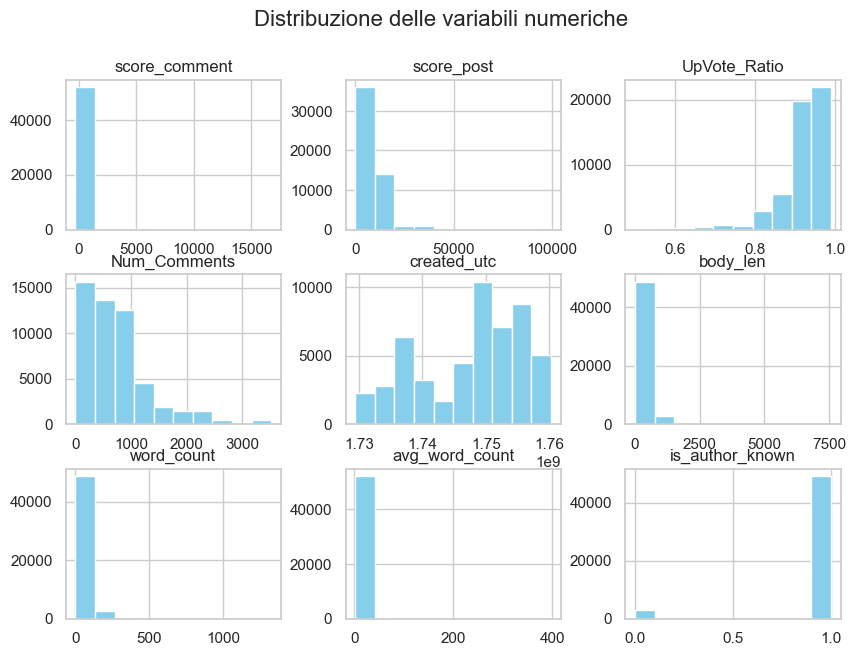

In [50]:
sns.set(style="whitegrid")
df_merged.hist(bins=10, figsize=(10,7), color='skyblue')
plt.suptitle('Distribuzione delle variabili numeriche', fontsize=16)
plt.show()

### Matrice di correlazione

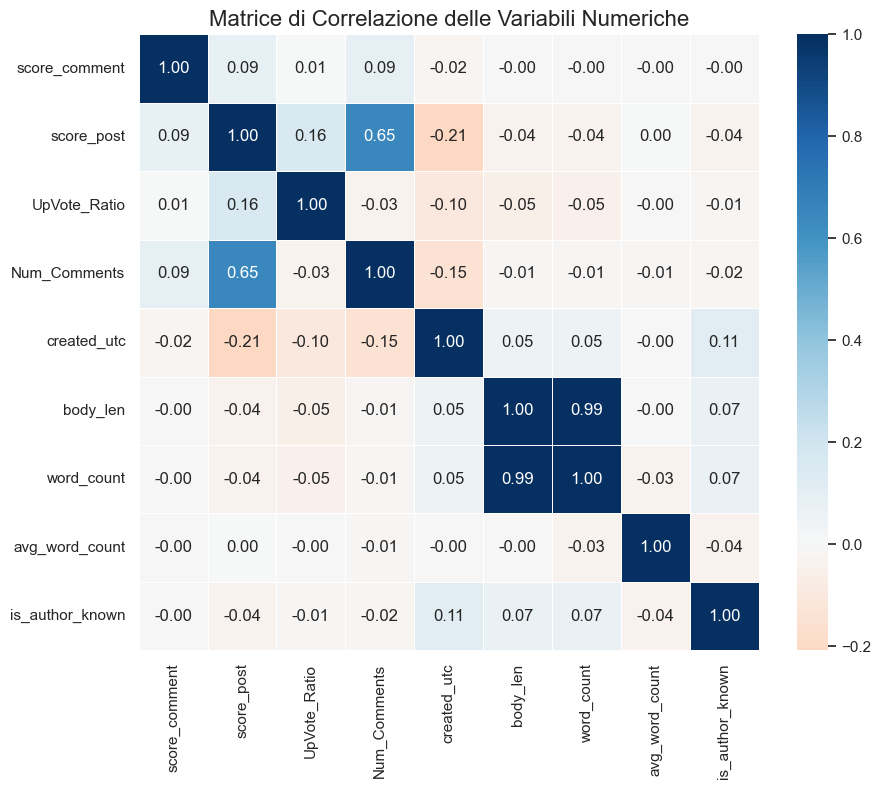

In [51]:
numerical_df = df_merged.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', linewidths=0.5, fmt='.2f', center=0)
plt.title('Matrice di Correlazione delle Variabili Numeriche', fontsize=16)
plt.show()

Approfondire lo studio se esiste il legame tra score_post e Num_Comments

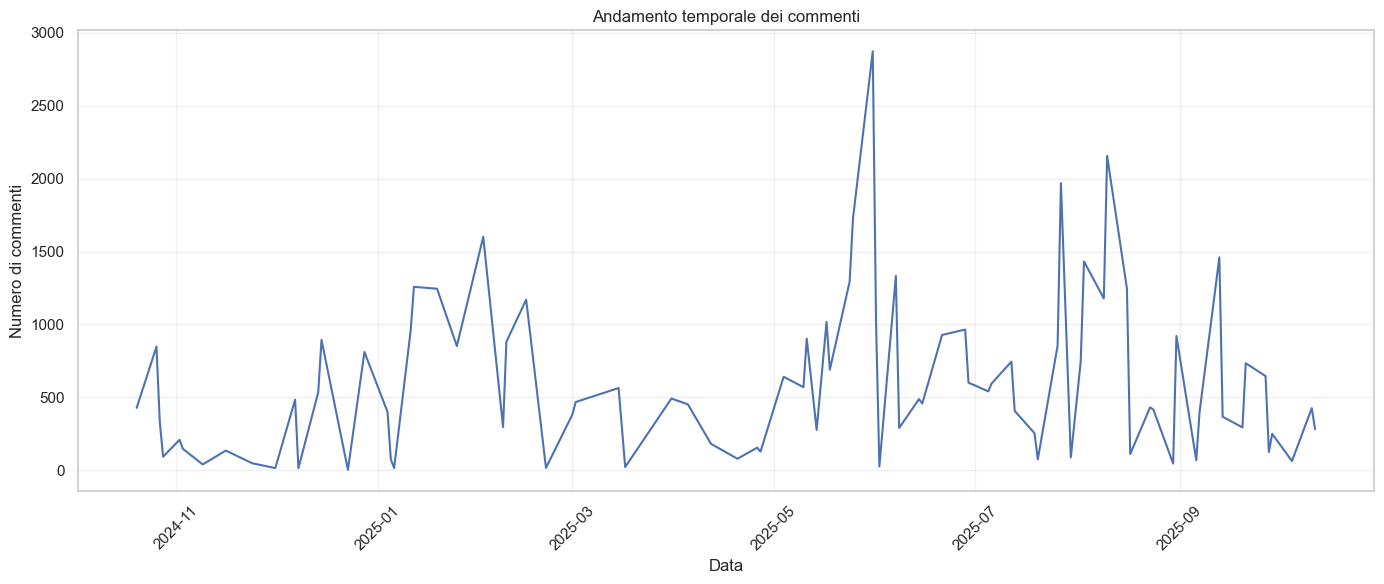

Prima data: 2024-10-20 15:19:59
Ultima data: 2025-10-12 13:15:10
Periodo totale: 356 giorni
Media commenti al giorno: 599.30


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Converti da Unix timestamp a datetime (specificando l'unità 's' per secondi)
df_merged['created_utc'] = pd.to_datetime(df_merged['created_utc'], unit='s')

# Ordina per data
df_merged = df_merged.sort_values('created_utc')

# Conta i commenti per giorno
commenti_giornalieri = df_merged.groupby(df_merged['created_utc'].dt.date).size()

# Crea il grafico
plt.figure(figsize=(14, 6))
plt.plot(commenti_giornalieri.index, commenti_giornalieri.values, linewidth=1.5)
plt.xlabel('Data')
plt.ylabel('Numero di commenti')
plt.title('Andamento temporale dei commenti')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stampa statistiche di base
print(f"Prima data: {df_merged['created_utc'].min()}")
print(f"Ultima data: {df_merged['created_utc'].max()}")
print(f"Periodo totale: {(df_merged['created_utc'].max() - df_merged['created_utc'].min()).days} giorni")
print(f"Media commenti al giorno: {commenti_giornalieri.mean():.2f}")

## Text mining

In [53]:
print(df_merged['body'].head(5))

30321    "Anthropic today announced a sweeping update t...
30320    Is this one of those headlines that pop up in ...
30322    thats great! surely AGI can't figure out a way...
30323    It's already been thought of, and it's called ...
30324    ... Which Asimov wrote extensively about how t...
Name: body, dtype: object


1. Rendere tutto minuscolo

In [54]:
df_merged['body']=df_merged['body'].str.lower()
print(df_merged['body'].head(5))

30321    "anthropic today announced a sweeping update t...
30320    is this one of those headlines that pop up in ...
30322    thats great! surely agi can't figure out a way...
30323    it's already been thought of, and it's called ...
30324    ... which asimov wrote extensively about how t...
Name: body, dtype: object


2. Rimuovere la punteggiatura

In [55]:
df_merged['body'] = df_merged['body'].str.replace(f"[{string.punctuation}]", "", regex=True)
print(df_merged['body'].head(5))

30321    anthropic today announced a sweeping update to...
30320    is this one of those headlines that pop up in ...
30322    thats great surely agi cant figure out a way a...
30323    its already been thought of and its called the...
30324     which asimov wrote extensively about how they...
Name: body, dtype: object


3. Rimoviamo gli "\n"

In [56]:
df_merged['body'] = df_merged['body'].str.replace('\n', '', regex=True)
print(df_merged['body'].head(5))


30321    anthropic today announced a sweeping update to...
30320    is this one of those headlines that pop up in ...
30322    thats great surely agi cant figure out a way a...
30323    its already been thought of and its called the...
30324     which asimov wrote extensively about how they...
Name: body, dtype: object


4. Rimuovere le stopwords

In [57]:
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words

def preprocess_spacy(text):
    doc = nlp(text.lower()) 
    return ' '.join([token.text for token in doc if token.is_alpha and token.text not in stop_words])

df_merged['body'] = df_merged['body'].apply(preprocess_spacy)
print(df_merged['body'].head(5))


30321    anthropic today announced sweeping update resp...
30320    headlines pop introductory minutes horror movi...
30322                     s great surely agi nt figure way
30323                         thought called laws robotics
30324    asimov wrote extensively flawedthe issue entir...
Name: body, dtype: object


1. parole più frequenti

In [58]:
all_words = ' '.join(df_merged['body']).split()

word_counts = Counter(all_words)
most_common_words = word_counts.most_common
print(most_common_words(10))

[('ai', 26717), ('nt', 18157), ('people', 14140), ('like', 9684), ('work', 6529), ('think', 6477), ('s', 5997), ('going', 5360), ('need', 4882), ('time', 4549)]


In [59]:
word_counts_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count'])
word_counts_df = word_counts_df.sort_values(by='Count', ascending=False)
print(word_counts_df)

                     Word  Count
14                     ai  26717
108                    nt  18157
357                people  14140
145                  like   9684
189                  work   6529
...                   ...    ...
19620  netherlandsfinally      1
19623             assuage      1
36205               needi      1
36204     transactionwhen      1
26391         aiaugmented      1

[52782 rows x 2 columns]


NT probably stand for new techonlogy

Primo grafico per le 10 parole più frequenti

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_39795/3885132153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=word_counts_df.head(10), palette='viridis')


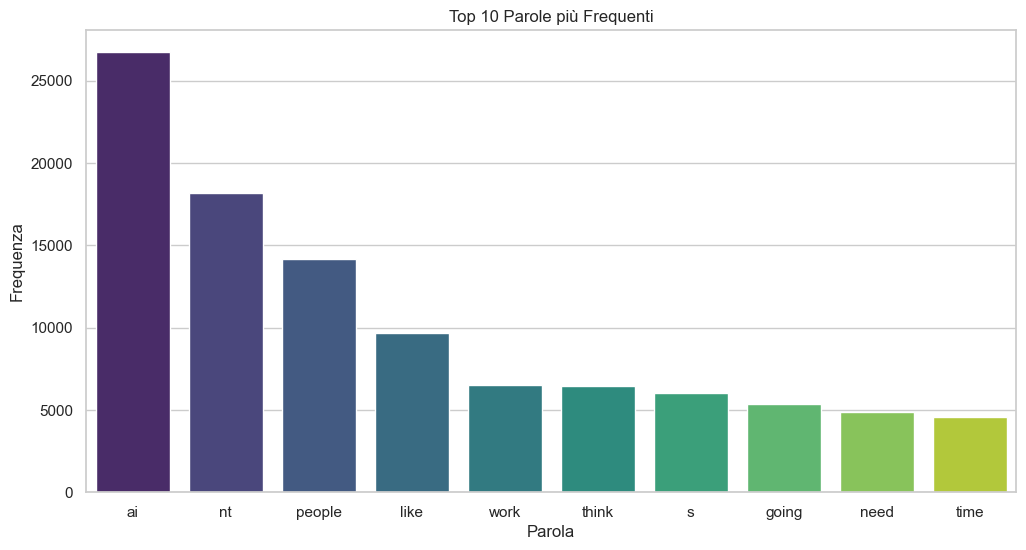

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Word', y='Count', data=word_counts_df.head(10), palette='viridis')
plt.title('Top 10 Parole più Frequenti')
plt.xlabel('Parola')
plt.ylabel('Frequenza')
plt.show()

WordCloud

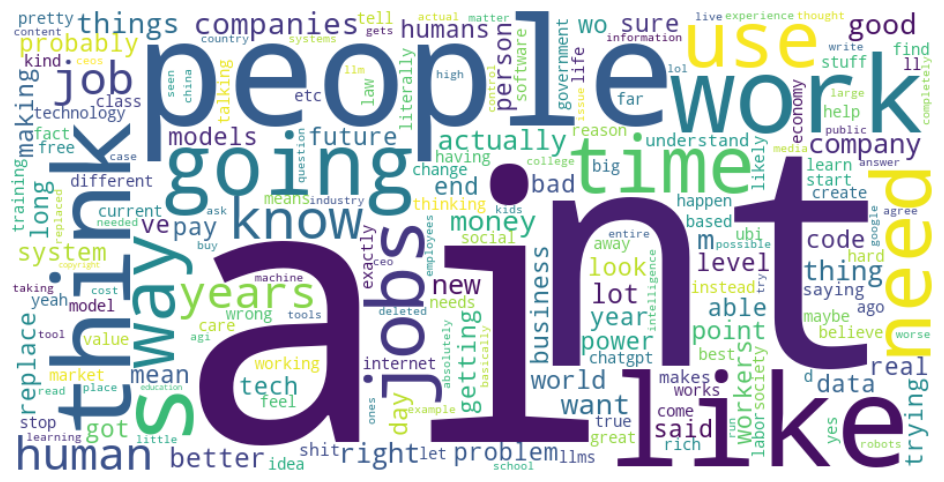

In [61]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

2. Bigrammi

10 bigrammi più comuni:
[(('wo', 'nt'), 1569), (('ai', 'nt'), 846), (('use', 'ai'), 799), (('gon', 'na'), 755), (('nt', 'know'), 724), (('nt', 'think'), 661), (('people', 'nt'), 639), (('nt', 'need'), 627), (('years', 'ago'), 587), (('entry', 'level'), 513), (('nt', 'want'), 456), (('social', 'media'), 452), (('ai', 'companies'), 418), (('gen', 'z'), 387), (('nt', 'understand'), 351)]


/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_39795/1998537663.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='bigram', data=df_bigram, palette='Blues_d')


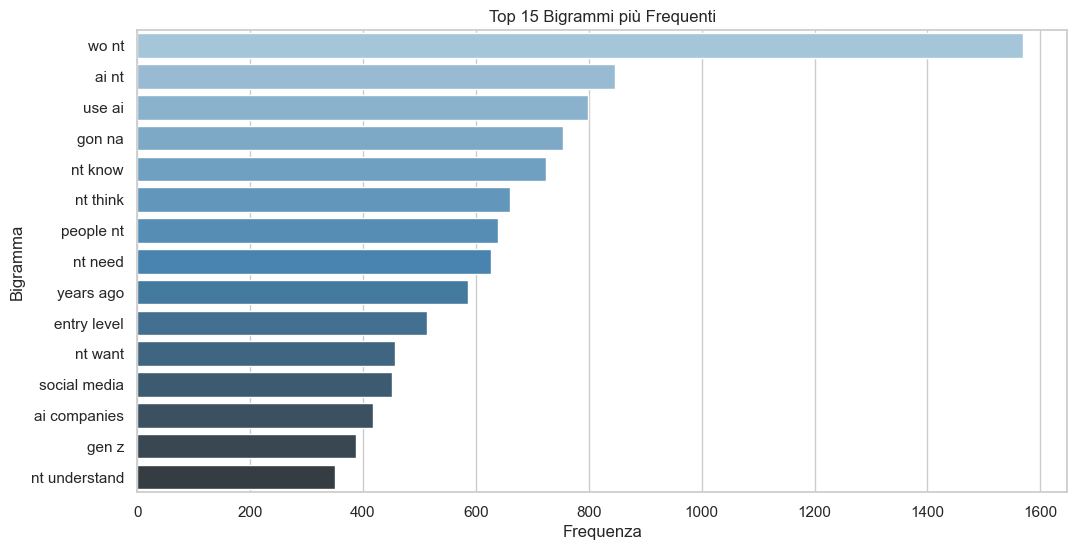

In [62]:
all_tokens = ' '.join(df_merged['body']).split()

bigram_freq = Counter(nltk.bigrams(all_tokens))

print('10 bigrammi più comuni:')
print(bigram_freq.most_common(15))

df_bigram = pd.DataFrame(bigram_freq.most_common(15), columns=['Bigram', 'Count'])
df_bigram['bigram'] = df_bigram['Bigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='bigram', data=df_bigram, palette='Blues_d')
plt.title('Top 15 Bigrammi più Frequenti')
plt.xlabel('Frequenza')
plt.ylabel('Bigramma')
plt.show()

WO prob stands for writing your own algorithms

3. Trigrammi

10 trigrammi più comuni:
[(('following', 'submission', 'statement'), 156), (('submission', 'statement', 'provided'), 156), (('reply', 'ops', 'comment'), 156), (('post', 'mass', 'deleted'), 146), (('mass', 'deleted', 'anonymized'), 146), (('deleted', 'anonymized', 'redacthttpsredactdevhome'), 146), (('entry', 'level', 'jobs'), 142), (('ha', 'ha', 'ha'), 104), (('white', 'collar', 'jobs'), 103), (('universal', 'basic', 'income'), 86), (('ai', 'wo', 'nt'), 84), (('wo', 'nt', 'able'), 78), (('statement', 'provided', 'article'), 62), (('blue', 'collar', 'jobs'), 56), (('critical', 'thinking', 'skills'), 56)]


/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_39795/2428586689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='trigram', data=df_trigram, palette='Greens_d')


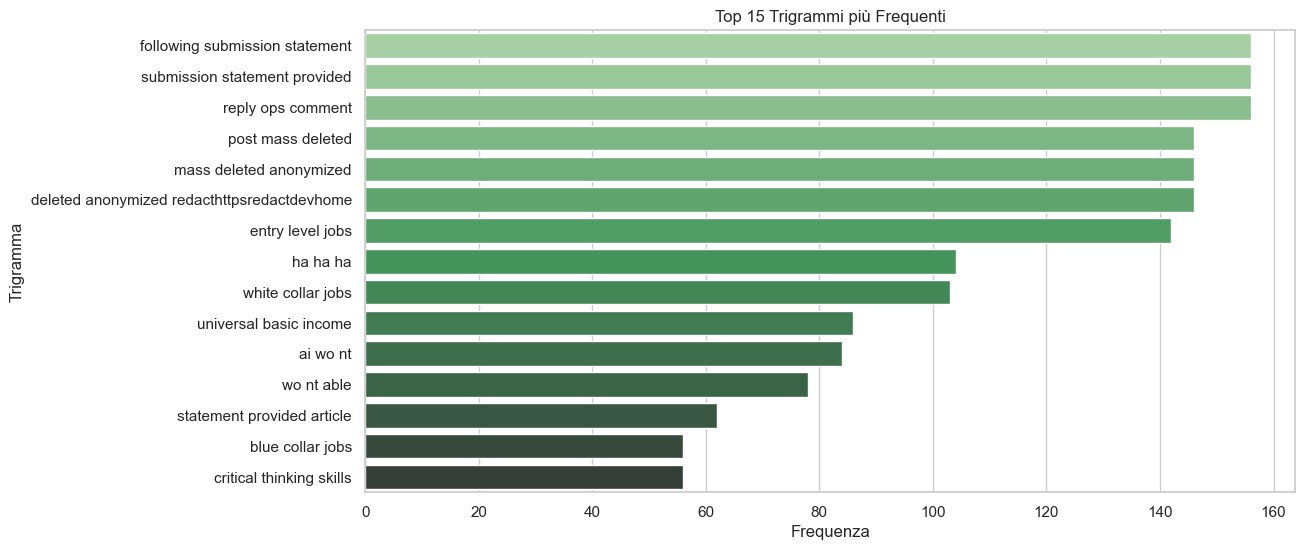

In [63]:
trigram_freq = Counter(nltk.trigrams(all_tokens))

print('10 trigrammi più comuni:')
print(trigram_freq.most_common(15))

df_trigram = pd.DataFrame(trigram_freq.most_common(15), columns=['Trigram', 'Count'])
df_trigram['trigram'] = df_trigram['Trigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='trigram', data=df_trigram, palette='Greens_d')
plt.title('Top 15 Trigrammi più Frequenti')
plt.xlabel('Frequenza')
plt.ylabel('Trigramma')
plt.show()

## Emotion text classifier


### Analizzare i sentimenti - basic

In [49]:
from sentiment_analysis_modular import analizza_sentiment_completo
df_merged = analizza_sentiment_completo(df_merged, colonna_testo='body')

/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caricamento modello 1...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Caricamento modello 5...


Device set to use mps:0


...

/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/sentiment_analysis_modular.py:115: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[nome_colonna_risultato] = df[nome_colonna_risultato].replace(mapping)


Analisi in corso per Ris_7...


/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/sentiment_analysis_modular.py:115: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[nome_colonna_risultato] = df[nome_colonna_risultato].replace(mapping)


Analisi in corso per Ris_Chelberta...
Calcolo ensemble finale...
✅ Analisi completata!


/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/sentiment_analysis_modular.py:115: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[nome_colonna_risultato] = df[nome_colonna_risultato].replace(mapping)


In [50]:
df_merged.head()

,post_id,search_topic,comment_id,author,body,score_comment,Title,score_post,UpVote_Ratio,Num_Comments,...,body_len,word_count,avg_word_count,macro_topic,is_author_known,Ris_1,Ris_5,Ris_7,Ris_Chelberta,Final_ensemble
30321,1g8134i,Regolamentazione e AI,lsuq2vb,MetaKnowing,anthropic today announced sweeping update resp...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,...,1545,201,7.686567,Impatto Socio-Economico e Governance,1,0,0,1,0,1
30320,1g8134i,Regolamentazione e AI,lsypkn5,BorderKeeper,headlines pop introductory minutes horror movi...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,...,140,26,5.384615,Impatto Socio-Economico e Governance,1,0,0,-1,0,-1
30322,1g8134i,Regolamentazione e AI,lsv3zpo,frankcast554,s great surely agi nt figure way,7,Anthropic just made it harder for AI to go rog...,225,0.88,12,...,57,11,5.181818,Impatto Socio-Economico e Governance,1,1,1,1,1,1
30323,1g8134i,Regolamentazione e AI,lsxee20,2D-Renderman,thought called laws robotics,0,Anthropic just made it harder for AI to go rog...,225,0.88,12,...,74,13,5.692308,Impatto Socio-Economico e Governance,1,0,0,0,0,0
30324,1g8134i,Regolamentazione e AI,lsyiu0x,FableFinale,asimov wrote extensively flawedthe issue entir...,4,Anthropic just made it harder for AI to go rog...,225,0.88,12,...,206,36,5.722222,Impatto Socio-Economico e Governance,1,-1,0,-1,-1,-1


In [55]:
# Elimina le colonne specificate
df_merged = df_merged.drop(columns=['Ris_1', 'Ris_5', 'Ris_7', 'Ris_Chelberta'])

# Rinomina la colonna Final_ensemble in Sentiment
df_merged = df_merged.rename(columns={'Final_ensemble': 'Sentiment'})

In [2]:
df_merged.to_csv('RedditSentimentBasicAnalysis.csv', index=False)

NameError: name 'df_merged' is not defined

In [4]:
percorso_file = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/RedditSentimentBasicAnalysis.csv'
df_merged = pd.read_csv(percorso_file)

In [5]:
df_merged.head()

,post_id,search_topic,comment_id,author,body,score_comment,Title,score_post,UpVote_Ratio,Num_Comments,created_utc,body_len,word_count,avg_word_count,macro_topic,is_author_known,Sentiment
0,1g8134i,Regolamentazione e AI,lsuq2vb,MetaKnowing,anthropic today announced sweeping update resp...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,1545,201,7.686567,Impatto Socio-Economico e Governance,1,1
1,1g8134i,Regolamentazione e AI,lsypkn5,BorderKeeper,headlines pop introductory minutes horror movi...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,140,26,5.384615,Impatto Socio-Economico e Governance,1,-1
2,1g8134i,Regolamentazione e AI,lsv3zpo,frankcast554,s great surely agi nt figure way,7,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,57,11,5.181818,Impatto Socio-Economico e Governance,1,1
3,1g8134i,Regolamentazione e AI,lsxee20,2D-Renderman,thought called laws robotics,0,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,74,13,5.692308,Impatto Socio-Economico e Governance,1,0
4,1g8134i,Regolamentazione e AI,lsyiu0x,FableFinale,asimov wrote extensively flawedthe issue entir...,4,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,206,36,5.722222,Impatto Socio-Economico e Governance,1,-1


#### 1. Semplice istogramma con negativo / neutro / positivo

Sentiment
-1    21896
 0    15803
 1    14440
Name: count, dtype: int64


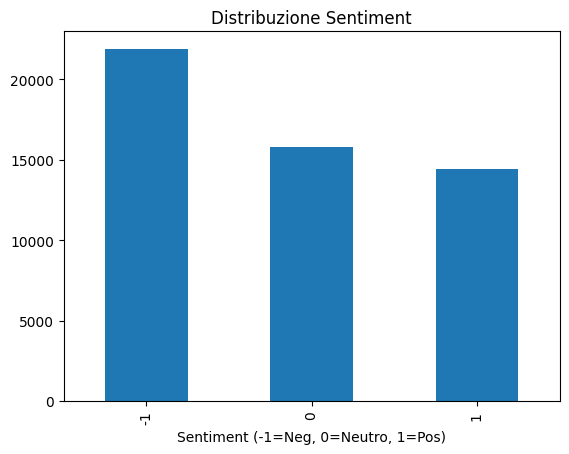

In [6]:
df_merged['Sentiment'].value_counts()
df_merged['Sentiment'].value_counts(normalize=True) * 100

print(df_merged['Sentiment'].value_counts())

df_merged['Sentiment'].value_counts().plot(kind='bar')
plt.title('Distribuzione Sentiment')
plt.xlabel('Sentiment (-1=Neg, 0=Neutro, 1=Pos)')
plt.show()

#### 2. Qual'è il valore medio del sentimento per i macro_topic?


Raggruppo il mio df per 'macro_topic' e successivamente mostro sia la media che il count della mia colonna 'Final_ensemble' 

In [7]:
sentiment_per_topic = df_merged.groupby('macro_topic')['Sentiment'].agg(['mean', 'count'])
sentiment_per_topic.head()

,mean,count
macro_topic,,
AGI e Sviluppo Tecnologico,-0.154609,19255
Impatto Socio-Economico e Governance,-0.137054,22597
"Rischi, Etica e Sicurezza",-0.134344,10287


#### 3. Qual'è invece il valore medio degli score dei commenti raggruppandoli per i vari sentimenti?

In questo caso raggruppo 'Final_ensemble' e successivamente mostro la media degli score_comment.

In [8]:
df_merged.groupby('Sentiment')['score_comment'].mean()

Sentiment
-1    31.698621
 0    29.259571
 1    20.164889
Name: score_comment, dtype: float64

#### 4. Esiste correlazione tra sentimento pos/neu/neg e score finale del post / commento?

Procedo con creare una correlazione tra le variabili "Final_ensemble", "score_comment" e "score_post"

In [9]:
df_merged[['Sentiment', 'score_comment', 'score_post']].corr()

,Sentiment,score_comment,score_post
Sentiment,1.000000,-0.019478,-0.031549
score_comment,-0.019478,1.000000,0.085433
score_post,-0.031549,0.085433,1.000000


In [10]:
df_merged[['Sentiment', 'score_comment', 'score_post']].corr(method='spearman')

,Sentiment,score_comment,score_post
Sentiment,1.000000,-0.028190,-0.035493
score_comment,-0.028190,1.000000,0.213071
score_post,-0.035493,0.213071,1.000000


#### 5. Considerando i post con più commenti, quale è generlmente il loro sentimento medio?

In questo caso procedo a raggruppare per 'post_id' successivamente considerò 'Final_ensemble' come media, mentre per 'Num_Comments', 'score_post' e 'Title' il primo (si ipotizza essere uguali per tutti quanti). In fondo viene messo un comando per mostrare come output decrescente.

In [11]:
post_analysis = df_merged.groupby('post_id').agg({
    'Sentiment': 'mean',
    'Num_Comments': 'first',
    'score_post': 'first',
    'Title': 'first'
}).sort_values('Num_Comments', ascending=False)
post_analysis.head()

,Sentiment,Num_Comments,score_post,Title
post_id,,,,
1h8h483,-0.318182,3523,99503,Murdered Insurance CEO Had Deployed an AI to A...
1jnqxqm,-0.111789,2599,8712,"Bill Gates: Within 10 years, AI will replace m..."
1maq7ut,-0.208925,2192,14073,Andrew Yang says a partner at a prominent law ...
1hzvcbd,-0.116667,1893,15040,Mark Zuckerberg said Meta will start automatin...
1lmncmi,-0.173387,1872,15168,"People Are Being Involuntarily Committed, Jail..."


#### 6. Considera la giornate e l'ora esiste una giornata / momento nella giornata in cui i commenti sono più positivi o negativi? e se invece considerassimo tutto l'arco delle analisi? ci sono periodi in cui i commenti sono più positivi?


Prima di tutto trasformo 'created_utc' in un'orario leggibile. Successivamente per 'giorno_settimana' e 'ora' faccio due grafici

In [65]:
df_merged['data'] = pd.to_datetime(df_merged['created_utc'], unit='s')
df_merged['giorno_settimana'] = df_merged['data'].dt.day_name()
df_merged['ora'] = df_merged['data'].dt.hour
df_merged['anno_mese'] = df_merged['data'].dt.to_period('M')

ValueError: non convertible value 2024-10-20 15:19:59 with the unit 's', at position 0

Text(0.5, 1.0, 'Sentiment durante la settimana')

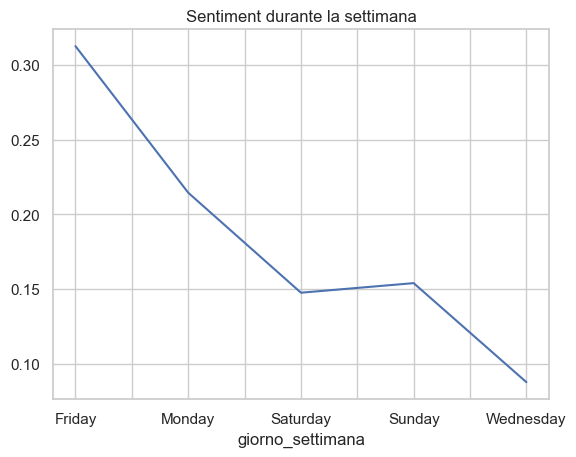

In [ ]:
# Sentiment per giorno della settimana
df_merged.groupby('giorno_settimana')['Sentiment'].mean().plot()
plt.title('Sentiment durante la settimana')

Text(0.5, 1.0, 'Sentiment durante il giorno')

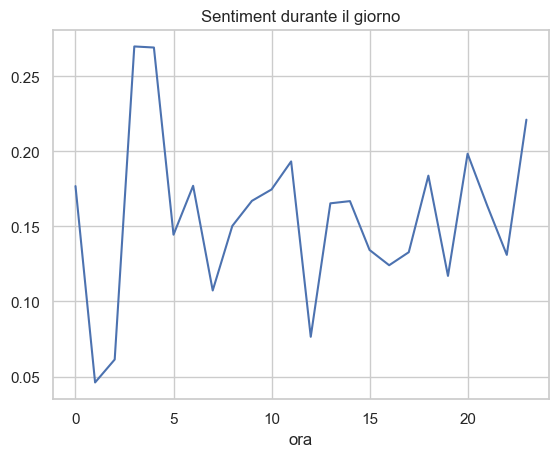

In [ ]:
# Sentiment per ora del giorno
df_merged.groupby('ora')['Sentiment'].mean().plot()
plt.title('Sentiment durante il giorno')

Text(0.5, 1.0, 'Sentiment per i mesi')

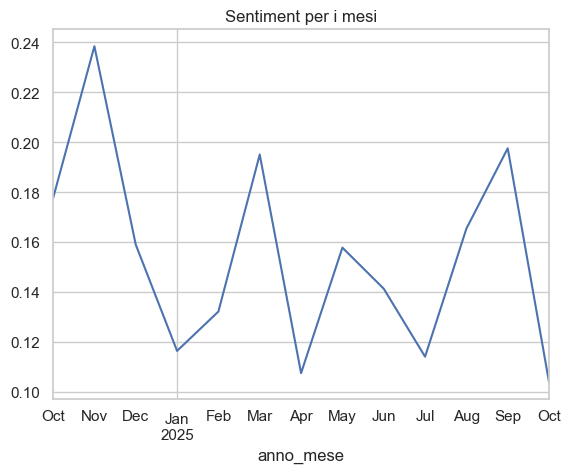

In [ ]:
# Sentiment per giorno della settimana
df_merged.groupby('anno_mese')['Sentiment'].mean().plot()
plt.title('Sentiment per i mesi')

#### 7. I post con più controversie (ovvero con valori di 'UpVote_Ratio' più basso) tendono ad avere commenti più negativi o positivi?

Divido 'UpVote_Ratio' in 5 intervalli uguali e successivamento raggruppo questi intervalli e mostro la media di 'Final_ensemble'.

In [66]:
df_merged.groupby(pd.cut(df_merged['UpVote_Ratio'], bins=5))['Sentiment'].mean()

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_8968/1361967260.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby(pd.cut(df_merged['UpVote_Ratio'], bins=5))['Sentiment'].mean()


UpVote_Ratio
(0.5, 0.598]      0.049645
(0.598, 0.696]    0.009208
(0.696, 0.794]   -0.056987
(0.794, 0.892]   -0.093731
(0.892, 0.99]    -0.158138
Name: Sentiment, dtype: float64

### Analizzare i sentimenti - tutte le emozione 

In [67]:
from emotion_recognition import analizza_emozioni_completo

df_merged = analizza_emozioni_completo(df_merged, colonna_testo='body')

print(df_merged[['body', 'emotion', 'emotion_score']].head())

ANALISI EMOZIONI - Modello j-hartmann
Caricamento modello emotion (j-hartmann)...


Device set to use mps:0



✓ Modello caricato con successo!
Inizio analisi di 52139 testi...
  Processati: 0/52139 testi...
  Processati: 100/52139 testi...
  Processati: 200/52139 testi...
  Processati: 300/52139 testi...
  Processati: 400/52139 testi...
  Processati: 500/52139 testi...
  Processati: 600/52139 testi...
  Processati: 700/52139 testi...
  Processati: 800/52139 testi...
  Processati: 900/52139 testi...
  Processati: 1000/52139 testi...
  Processati: 1100/52139 testi...
  Processati: 1200/52139 testi...
  Processati: 1300/52139 testi...
  Processati: 1400/52139 testi...
  Processati: 1500/52139 testi...
  Processati: 1600/52139 testi...
  Processati: 1700/52139 testi...
  Processati: 1800/52139 testi...
  Processati: 1900/52139 testi...
  Processati: 2000/52139 testi...
  Processati: 2100/52139 testi...
  Processati: 2200/52139 testi...
  Processati: 2300/52139 testi...
  Processati: 2400/52139 testi...
  Processati: 2500/52139 testi...
  Processati: 2600/52139 testi...
  Processati: 2700/52139 te

In [68]:
df_merged.to_csv('RedditSentimentFullAnalysis.csv', index=False)

In [69]:
percorso_file = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/RedditSentimentFullAnalysis.csv'
df_merged = pd.read_csv(percorso_file)

In [70]:
df_merged.head()

,post_id,search_topic,comment_id,author,body,score_comment,Title,score_post,UpVote_Ratio,Num_Comments,created_utc,body_len,word_count,avg_word_count,macro_topic,is_author_known,Sentiment,emotion,emotion_score
0,1g8134i,Regolamentazione e AI,lsuq2vb,MetaKnowing,anthropic today announced sweeping update resp...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,1545,201,7.686567,Impatto Socio-Economico e Governance,1,1,fear,0.6532
1,1g8134i,Regolamentazione e AI,lsypkn5,BorderKeeper,headlines pop introductory minutes horror movi...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,140,26,5.384615,Impatto Socio-Economico e Governance,1,-1,fear,0.9927
2,1g8134i,Regolamentazione e AI,lsv3zpo,frankcast554,s great surely agi nt figure way,7,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,57,11,5.181818,Impatto Socio-Economico e Governance,1,1,sadness,0.3995
3,1g8134i,Regolamentazione e AI,lsxee20,2D-Renderman,thought called laws robotics,0,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,74,13,5.692308,Impatto Socio-Economico e Governance,1,0,neutral,0.5483
4,1g8134i,Regolamentazione e AI,lsyiu0x,FableFinale,asimov wrote extensively flawedthe issue entir...,4,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,206,36,5.722222,Impatto Socio-Economico e Governance,1,-1,neutral,0.5603


#### 1. Conta sia i valori che in percentuale i vari sentimenti, poi procedi a creare un istogramma con i risultati ottenuti

Conteggi:
emotion
neutral     19669
anger        8511
joy          6689
sadness      6338
surprise     6127
fear         4204
disgust       601
Name: count, dtype: int64

Percentuali:
emotion
neutral     37.724160
anger       16.323673
joy         12.829168
sadness     12.155968
surprise    11.751280
fear         8.063062
disgust      1.152688
Name: proportion, dtype: float64


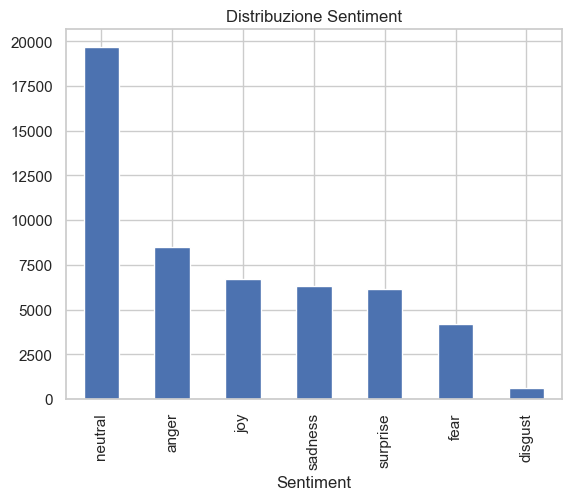

In [71]:
emotion_counts = df_merged['emotion'].value_counts()
emotion_percentages = df_merged['emotion'].value_counts(normalize=True) * 100

print("Conteggi:")
print(emotion_counts)
print("\nPercentuali:")
print(emotion_percentages)

emotion_counts.plot(kind='bar')
plt.title('Distribuzione Sentiment')
plt.xlabel('Sentiment')
plt.show()

#### 2. Visualizza per ogni 'macro_topic' il numero assoluto e la percentuale di ciascuna emozione

Per ciascun 'macro_topic' procedo a contare le emozioni sia in valore assoluto che in valore percentuale e procedo poi a creare una tabella

In [72]:
for topic in df_merged['macro_topic'].unique():
    print('='*50)
    print(f"MACRO_TOPIC: {topic}")
    print('='*50)
    
    topic_data = df_merged[df_merged['macro_topic'] == topic]
    emotion_counts = topic_data['emotion'].value_counts()
    emotion_pct = topic_data['emotion'].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Conteggio': emotion_counts,
        'Percentuale': emotion_pct
    })
    print(summary)
    print('\n')

MACRO_TOPIC: Impatto Socio-Economico e Governance
          Conteggio  Percentuale
emotion                         
neutral        8405    37.195203
anger          3570    15.798557
joy            2909    12.873390
sadness        2839    12.563615
surprise       2823    12.492809
fear           1803     7.978935
disgust         248     1.097491


MACRO_TOPIC: AGI e Sviluppo Tecnologico
          Conteggio  Percentuale
emotion                         
neutral        7419    38.530252
anger          3126    16.234744
joy            2468    12.817450
sadness        2455    12.749935
surprise       2221    11.534666
fear           1306     6.782654
disgust         260     1.350299


MACRO_TOPIC: Rischi, Etica e Sicurezza
          Conteggio  Percentuale
emotion                         
neutral        3845    37.377272
anger          1815    17.643628
joy            1312    12.753961
fear           1095    10.644503
surprise       1083    10.527851
sadness        1044    10.148731
disgust  

#### 3. Visualizza per ogni 'macro_topic' il numero e percentuale delle emozioni senza considerare l'emozione NEUTRAL

Funziona praticamente come il punto 2.

In [73]:
df_no_neutral = df_merged[df_merged['emotion'] != 'neutral']

for topic in df_no_neutral['macro_topic'].unique():
    print(f"\n{'='*50}")
    print(f"MACRO_TOPIC: {topic}")
    print('='*50)
    
    topic_data = df_no_neutral[df_no_neutral['macro_topic'] == topic]
    emotion_counts = topic_data['emotion'].value_counts()
    emotion_pct = topic_data['emotion'].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Conteggio': emotion_counts,
        'Percentuale': emotion_pct
    })
    print(summary)


MACRO_TOPIC: Impatto Socio-Economico e Governance
          Conteggio  Percentuale
emotion                         
anger          3570    25.155017
joy            2909    20.497463
sadness        2839    20.004228
surprise       2823    19.891488
fear           1803    12.704340
disgust         248     1.747463

MACRO_TOPIC: AGI e Sviluppo Tecnologico
          Conteggio  Percentuale
emotion                         
anger          3126    26.410950
joy            2468    20.851639
sadness        2455    20.741805
surprise       2221    18.764785
fear           1306    11.034133
disgust         260     2.196688

MACRO_TOPIC: Rischi, Etica e Sicurezza
          Conteggio  Percentuale
emotion                         
anger          1815    28.174480
joy            1312    20.366346
fear           1095    16.997827
surprise       1083    16.811549
sadness        1044    16.206147
disgust          93     1.443651


#### 4. A quale emozione viene associato un maggior convolgimento degli utenti di reddit? (score_comment, score_post, num_comments e upvote_ratio)?

procedo a raggruppare per le emozio e poi per le varie variabili stampo sia la media che la mediana. Successivamente faccio un box plot per ciascuna delle mie variabili

=== SCORE MEDIO DEI COMMENTI PER EMOZIONE ===
         score_comment                score_post         Num_Comments         \
                  mean median     std       mean  median         mean median   
emotion                                                                        
anger            34.76    2.0  337.19    8796.46  7216.0       738.13  572.0   
disgust          39.76    3.0  267.54   10189.77  8323.0       750.33  634.0   
fear             28.18    2.0  183.67    7441.79  6180.0       720.78  640.0   
joy              27.40    2.0  275.67    8042.19  7216.0       744.42  658.0   
sadness          30.10    2.0  178.67    9181.08  8294.0       776.76  691.0   
surprise         28.84    2.0  260.52    8373.41  7389.0       759.99  658.0   

         UpVote_Ratio         
                 mean median  
emotion                       
anger            0.92   0.94  
disgust          0.93   0.94  
fear             0.92   0.93  
joy              0.92   0.94  
sadness         

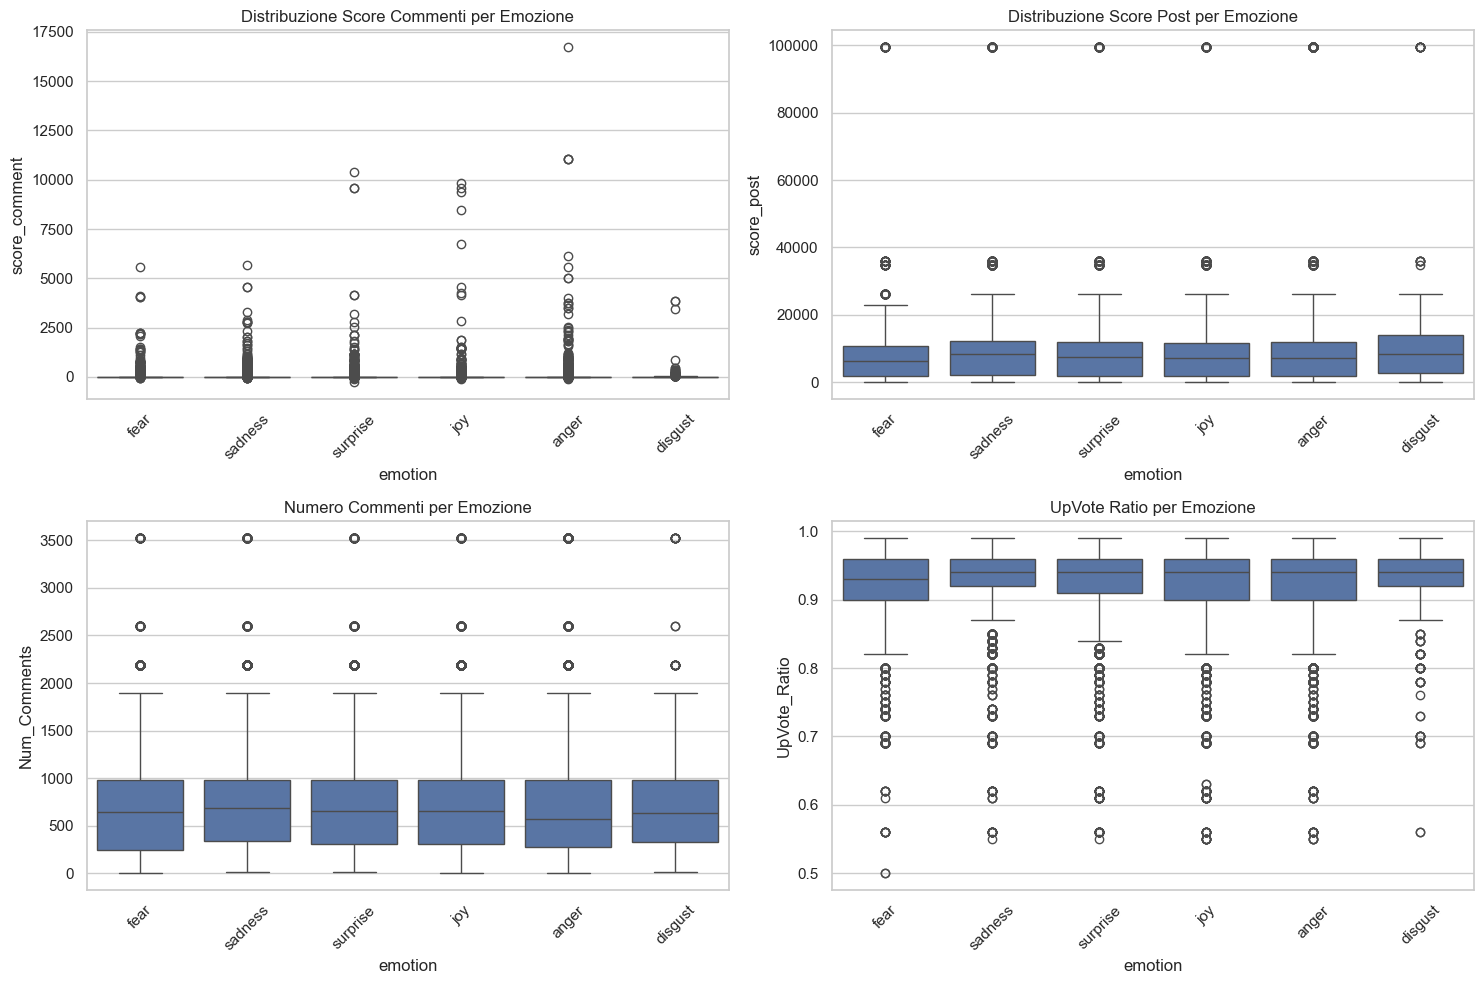

In [74]:
print("=== SCORE MEDIO DEI COMMENTI PER EMOZIONE ===")
engagement_stats = df_no_neutral.groupby('emotion').agg({
    'score_comment': ['mean', 'median', 'std'],
    'score_post': ['mean', 'median'],
    'Num_Comments': ['mean', 'median'],
    'UpVote_Ratio': ['mean', 'median']
}).round(2)
print(engagement_stats)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Score commenti per emozione
sns.boxplot(data=df_no_neutral, x='emotion', y='score_comment', ax=axes[0,0])
axes[0,0].set_title('Distribuzione Score Commenti per Emozione')
axes[0,0].tick_params(axis='x', rotation=45)

# Score post per emozione
sns.boxplot(data=df_no_neutral, x='emotion', y='score_post', ax=axes[0,1])
axes[0,1].set_title('Distribuzione Score Post per Emozione')
axes[0,1].tick_params(axis='x', rotation=45)

# Numero commenti per emozione
sns.boxplot(data=df_no_neutral, x='emotion', y='Num_Comments', ax=axes[1,0])
axes[1,0].set_title('Numero Commenti per Emozione')
axes[1,0].tick_params(axis='x', rotation=45)

# UpVote Ratio per emozione
sns.boxplot(data=df_no_neutral, x='emotion', y='UpVote_Ratio', ax=axes[1,1])
axes[1,1].set_title('UpVote Ratio per Emozione')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 5.1 Esiste alcun tipo di relazione tra la lunghezza di un commento e l'emozione espressa?

In maniera simile al punto 4. procedo ad analizzare le variabile 'body_len', 'word_count' e 'avg_word_count' e per i primi due procedo ad una raffigurazione grafica


=== ANALISI LUNGHEZZA TESTO PER EMOZIONE ===
         body_len                word_count               avg_word_count  \
             mean median     std       mean median    std           mean   
emotion                                                                    
anger      370.62  242.0  428.74      63.96   42.0  72.04           5.78   
disgust    138.38  113.0  119.35      24.14   20.0  19.02           5.71   
fear       448.25  291.0  461.15      76.81   50.0  76.99           5.80   
joy        371.75  250.0  446.88      65.05   44.0  74.48           5.70   
sadness    291.66  193.0  322.72      51.73   35.0  55.57           5.60   
surprise   321.69  211.0  363.04      56.19   37.0  60.88           5.69   

                 
         median  
emotion          
anger      5.68  
disgust    5.67  
fear       5.71  
joy        5.59  
sadness    5.54  
surprise   5.60  


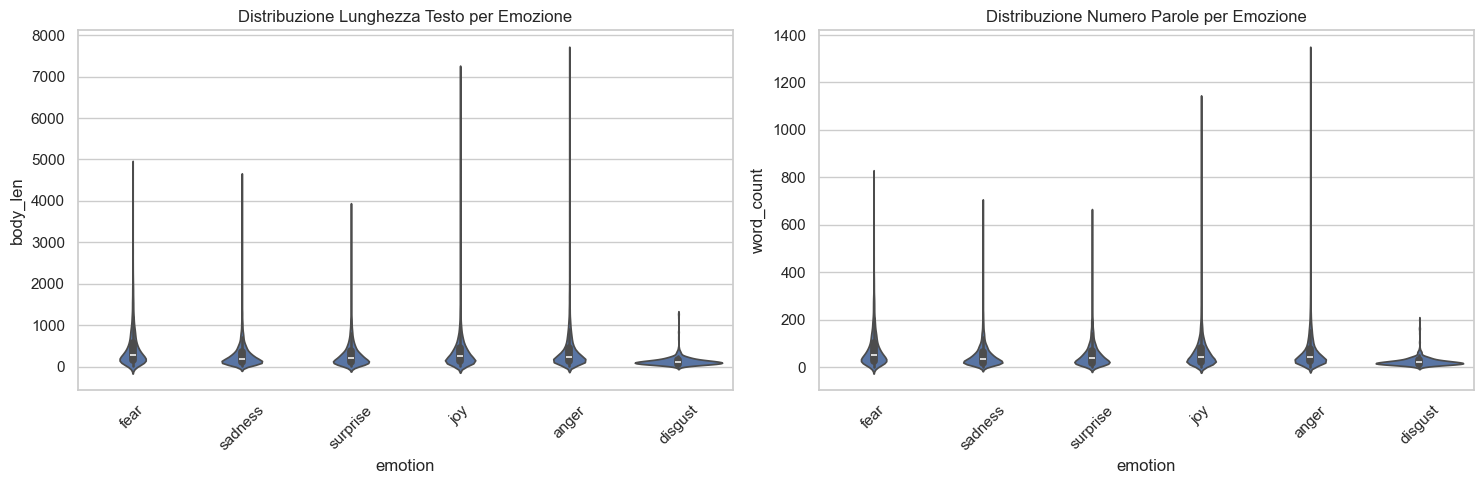

In [75]:
print("\n=== ANALISI LUNGHEZZA TESTO PER EMOZIONE ===")
text_stats = df_no_neutral.groupby('emotion').agg({
    'body_len': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std'],
    'avg_word_count': ['mean', 'median']
}).round(2)
print(text_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Lunghezza body per emozione
sns.violinplot(data=df_no_neutral, x='emotion', y='body_len', ax=axes[0])
axes[0].set_title('Distribuzione Lunghezza Testo per Emozione')
axes[0].tick_params(axis='x', rotation=45)

# Word count per emozione
sns.violinplot(data=df_no_neutral, x='emotion', y='word_count', ax=axes[1])
axes[1].set_title('Distribuzione Numero Parole per Emozione')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 5.2 Se un testo venisse diviso in molto brevi, brevi, medi e lunghi come sarebbe la distrubuzione della lunghezza per le varie emozioni?


=== DISTRIBUZIONE LUNGHEZZA PER EMOZIONE ===
emotion          anger  disgust   fear    joy  sadness  surprise
length_category                                                 
Molto brevi      19.59    53.74  16.86  21.59    26.78     27.94
Brevi            39.09    41.10  33.23  33.25    39.19     34.52
Medi             23.60     3.99  25.00  28.08    23.04     23.81
Lunghi           17.72     1.16  24.90  17.09    11.00     13.73


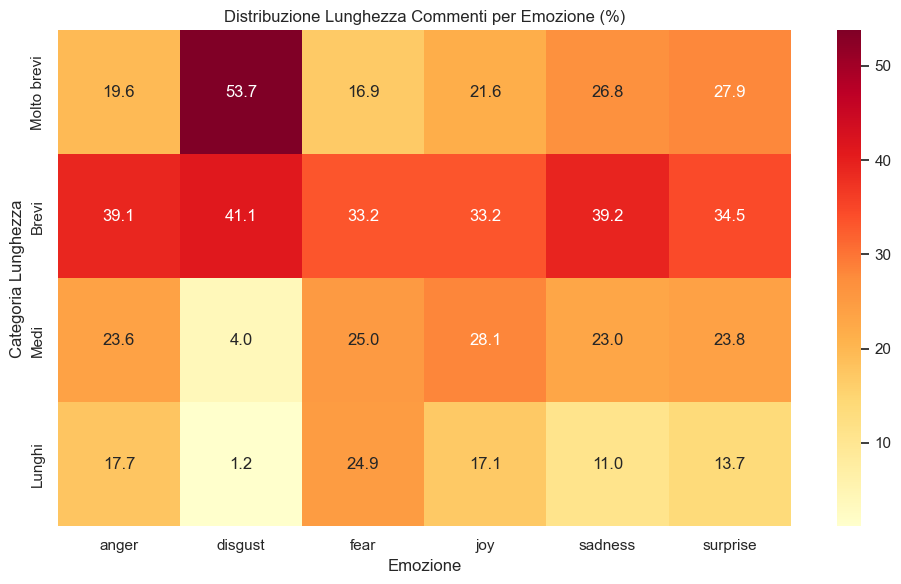

In [76]:
df_no_neutral['length_category'] = pd.cut(df_no_neutral['word_count'], 
                                           bins=[0, 20, 50, 100, float('inf')],
                                           labels=['Molto brevi', 'Brevi', 'Medi', 'Lunghi'])

print("\n=== DISTRIBUZIONE LUNGHEZZA PER EMOZIONE ===")
length_emotion = pd.crosstab(df_no_neutral['length_category'], 
                             df_no_neutral['emotion'], 
                             normalize='columns') * 100  
print(length_emotion.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(length_emotion, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Distribuzione Lunghezza Commenti per Emozione (%)')
plt.ylabel('Categoria Lunghezza')
plt.xlabel('Emozione')
plt.tight_layout()
plt.show()

In [77]:
from scipy.stats import chi2_contingency

# Crea la tabella di contingenza (frequenze assolute, non percentuali)
contingency_table = pd.crosstab(df_no_neutral['length_category'], 
                                 df_no_neutral['emotion'])

print("=== TABELLA DI CONTINGENZA ===")
print(contingency_table)
print()

# Esegui il test del Chi-quadrato
chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print("=== TEST CHI-QUADRATO ===")
print(f"Chi-quadrato: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Gradi di libertà: {dof}")
print(f"\nRisultato: {'SIGNIFICATIVO' if p_value < 0.05 else 'NON SIGNIFICATIVO'}")
print(f"(α = 0.05)")

=== TABELLA DI CONTINGENZA ===
emotion          anger  disgust  fear   joy  sadness  surprise
length_category                                               
Molto brevi       1667      323   709  1444     1697      1712
Brevi             3327      247  1397  2224     2484      2115
Medi              2009       24  1051  1878     1460      1459
Lunghi            1508        7  1047  1143      697       841

=== TEST CHI-QUADRATO ===
Chi-quadrato: 1107.8933
P-value: 0.0000
Gradi di libertà: 15

Risultato: SIGNIFICATIVO
(α = 0.05)


#### 6. Quali emozioni hanno una maggiore intensità nei commenti di reddit? esistono differenze tra le emozioni (pos e neg)?



=== STATISTICHE INTENSITÀ EMOTIVA (emotion_score) ===
          count   mean  median    std    min    max
emotion                                            
anger      8511  0.692   0.707  0.202  0.221  0.995
disgust     601  0.617   0.584  0.192  0.226  0.989
fear       4204  0.758   0.824  0.215  0.221  0.996
joy        6689  0.657   0.652  0.197  0.230  0.995
sadness    6338  0.645   0.631  0.201  0.225  0.993
surprise   6127  0.592   0.546  0.195  0.203  0.987


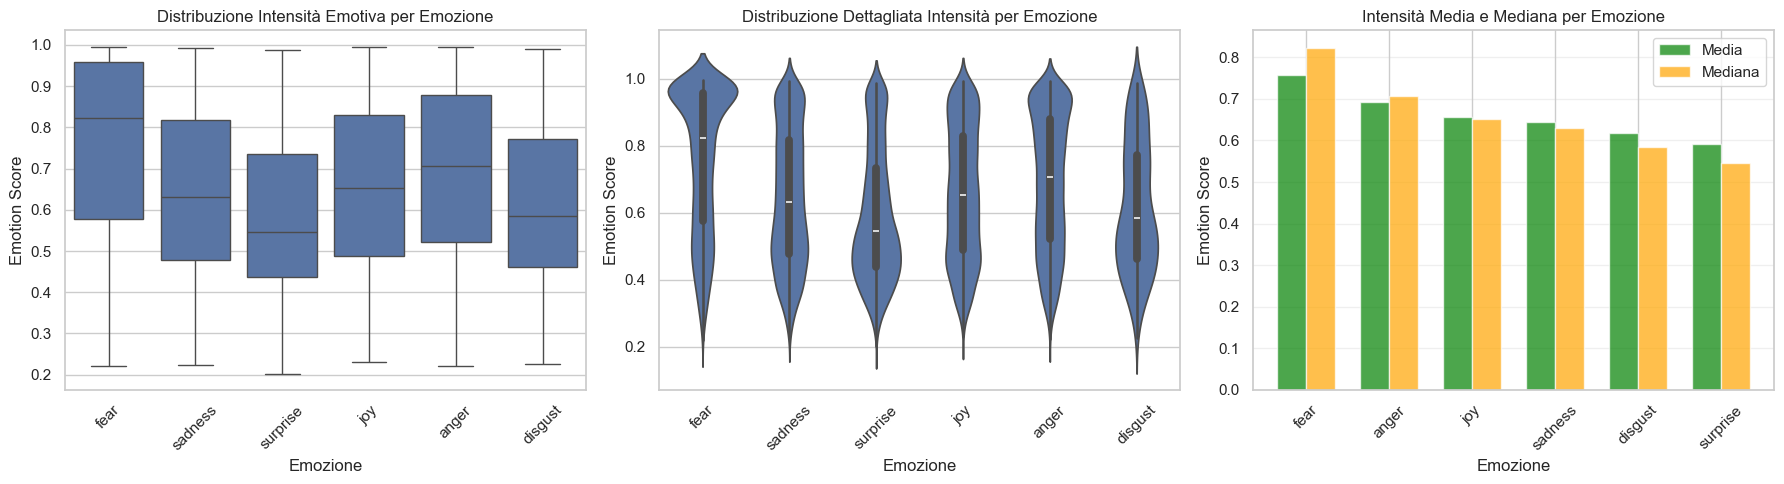

In [78]:
print("\n=== STATISTICHE INTENSITÀ EMOTIVA (emotion_score) ===")
intensity_stats = df_no_neutral.groupby('emotion')['emotion_score'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(3)
print(intensity_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Box plot
sns.boxplot(data=df_no_neutral, x='emotion', y='emotion_score', ax=axes[0])
axes[0].set_title('Distribuzione Intensità Emotiva per Emozione')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('Emozione')
axes[0].set_ylabel('Emotion Score')

# 2. Violin plot
sns.violinplot(data=df_no_neutral, x='emotion', y='emotion_score', ax=axes[1])
axes[1].set_title('Distribuzione Dettagliata Intensità per Emozione')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Emozione')
axes[1].set_ylabel('Emotion Score')

# 3. Bar plot 
intensity_summary = df_no_neutral.groupby('emotion')['emotion_score'].agg(['mean', 'median']).sort_values('mean', ascending=False)

x = range(len(intensity_summary))
width = 0.35

axes[2].bar([i - width/2 for i in x], intensity_summary['mean'], 
            width, label='Media', color='green', alpha=0.7)
axes[2].bar([i + width/2 for i in x], intensity_summary['median'], 
            width, label='Mediana', color='orange', alpha=0.7)

axes[2].set_title('Intensità Media e Mediana per Emozione')
axes[2].set_ylabel('Emotion Score')
axes[2].set_xlabel('Emozione')
axes[2].set_xticks(x)
axes[2].set_xticklabels(intensity_summary.index, rotation=45)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 7. Quali emozioni tendono ad ottenere una maggiore partecipazione (maggior engagement) sulla piattaforma reddit?

In [79]:
print("\n=== EFFICIENZA EMOTIVA (Score/Intensità) ===")
efficiency = df_no_neutral.groupby('emotion').agg({
    'emotion_score': 'mean',
    'score_comment': 'mean'
})
efficiency['efficienza'] = efficiency['score_comment'] / efficiency['emotion_score']
print(efficiency.sort_values('efficienza', ascending=False).round(3))


=== EFFICIENZA EMOTIVA (Score/Intensità) ===
          emotion_score  score_comment  efficienza
emotion                                           
disgust           0.617         39.759      64.438
anger             0.692         34.761      50.227
surprise          0.592         28.839      48.676
sadness           0.645         30.103      46.689
joy               0.657         27.395      41.716
fear              0.758         28.185      37.167


#### 8. analisi temporale

Senza considerare quando l'emozione è 'neutral' facciamo delle analisi temporali, quindi prima di tutto devo trasformare la variabil 'created_utc' successivamente creo 5 nuove colonne: data - anno - mese - giorno - ora - anno + mese

In [80]:
from datetime import datetime

df_merged['datetime'] = pd.to_datetime(df_merged['created_utc'], unit='s')
df_no_neutral = df_merged[df_merged['emotion'] != 'neutral'].copy()

df_no_neutral['date'] = df_no_neutral['datetime'].dt.date
df_no_neutral['year'] = df_no_neutral['datetime'].dt.year
df_no_neutral['month'] = df_no_neutral['datetime'].dt.month
df_no_neutral['day_of_week'] = df_no_neutral['datetime'].dt.day_name()
df_no_neutral['hour'] = df_no_neutral['datetime'].dt.hour
df_no_neutral['year_month'] = df_no_neutral['datetime'].dt.to_period('M')

print("=== RANGE TEMPORALE DEL DATASET ===")
print(f"Data inizio: {df_no_neutral['datetime'].min()}")
print(f"Data fine: {df_no_neutral['datetime'].max()}")
print(f"Durata: {(df_no_neutral['datetime'].max() - df_no_neutral['datetime'].min()).days} giorni")

ValueError: non convertible value 2024-10-20 15:19:59 with the unit 's', at position 0

#### 8.1 Come è stata durante il periodo di tempo analizzato l'evoluzione delle diverse emozioni?


=== EMOZIONI PER MESE ===
emotion     anger  disgust  fear  joy  sadness  surprise
year_month                                              
2024-10       181       13    67  110       61        52
2024-11        22        2    19   43       21        21
2024-12       263       31    79  196       91       103
2025-01       381       48   170  391      222       183
2025-02       347       30   278  257      211       148
2025-03       234       16    60  175       83        45
2025-04        94        3    31   75       34        42
2025-05       904       62   494  625      472       360
2025-06       566       40   402  383      338       223
2025-07       655       31   248  406      257       177
2025-08       817       79   286  582      426       324
2025-09       359       32   155  349      275       143
2025-10        64        8    30   41       47        28


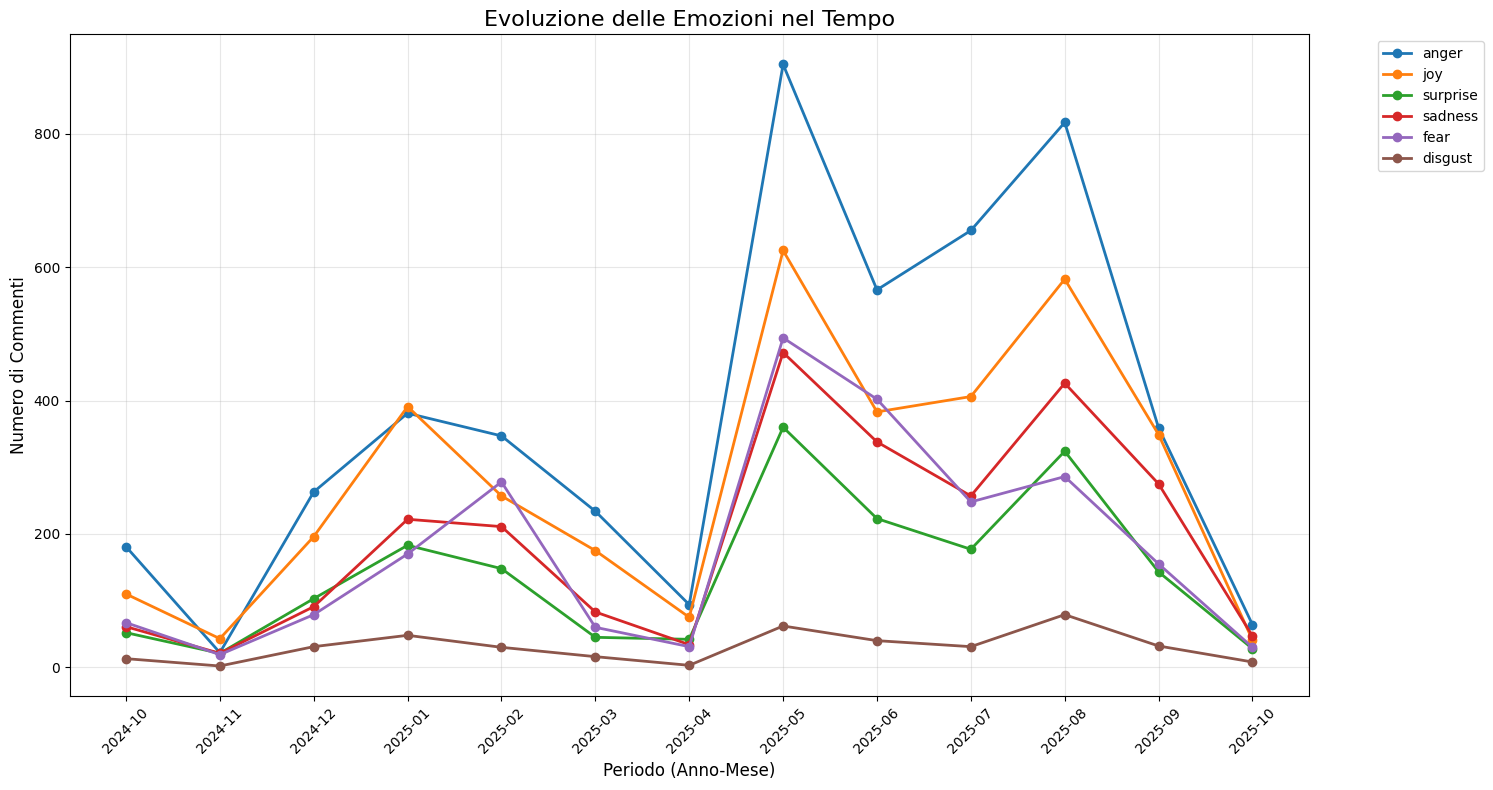

<Figure size 1500x800 with 0 Axes>

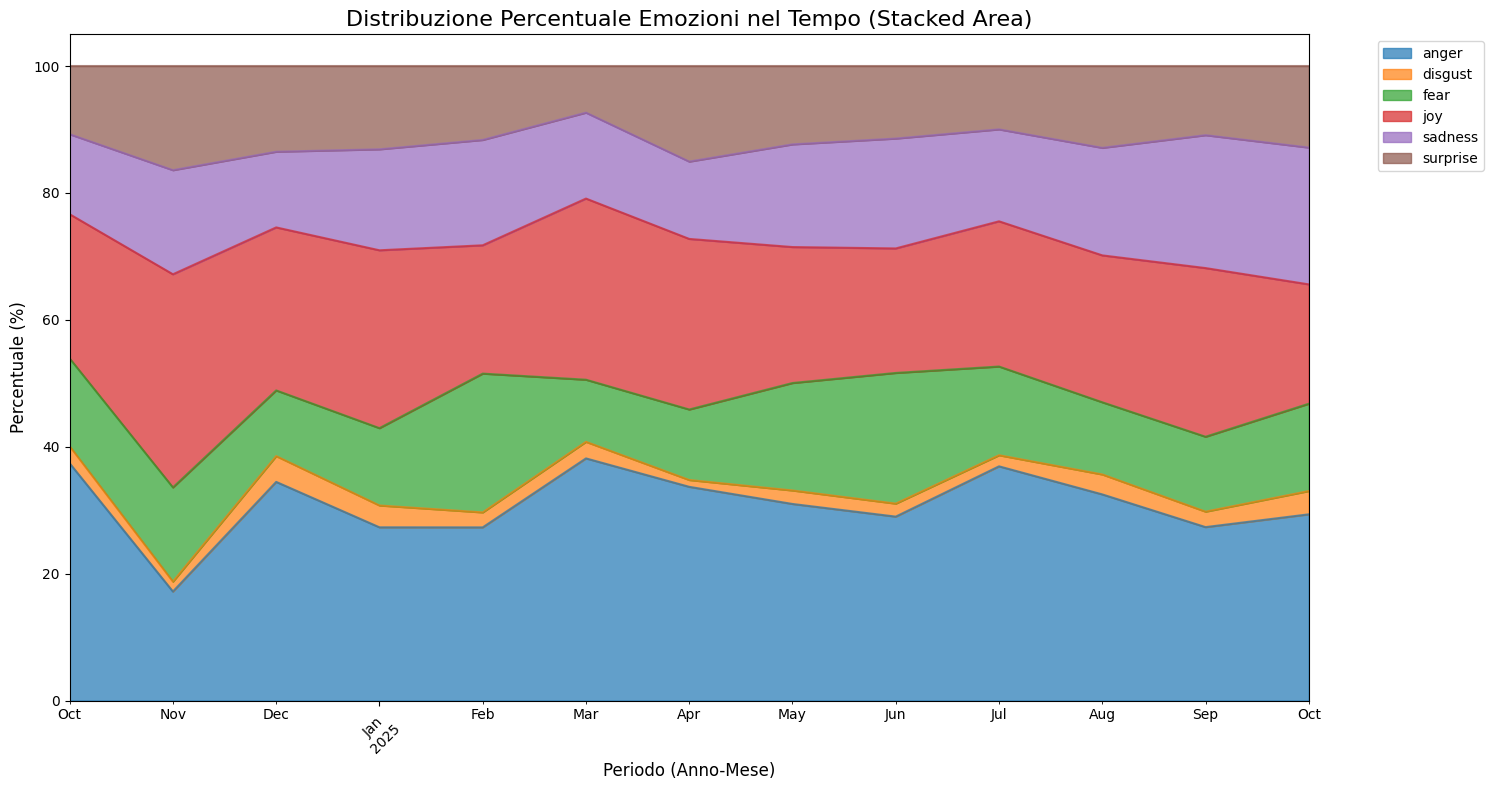

In [ ]:
print("\n=== EMOZIONI PER MESE ===")
emotions_by_month = df_no_neutral.groupby(['year_month', 'emotion']).size().unstack(fill_value=0)
print(emotions_by_month)

# Trend temporale
plt.figure(figsize=(15, 8))
for emotion in df_no_neutral['emotion'].unique():
    emotion_trend = df_no_neutral[df_no_neutral['emotion'] == emotion].groupby('year_month').size()
    plt.plot(emotion_trend.index.astype(str), emotion_trend.values, marker='o', label=emotion, linewidth=2)

plt.title('Evoluzione delle Emozioni nel Tempo', fontsize=16)
plt.xlabel('Periodo (Anno-Mese)', fontsize=12)
plt.ylabel('Numero di Commenti', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Percentuali normalizzate nel tempo
emotions_pct_month = df_no_neutral.groupby(['year_month', 'emotion']).size().unstack(fill_value=0)
emotions_pct_month = emotions_pct_month.div(emotions_pct_month.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 8))
emotions_pct_month.plot(kind='area', stacked=True, alpha=0.7, figsize=(15, 8))
plt.title('Distribuzione Percentuale Emozioni nel Tempo (Stacked Area)', fontsize=16)
plt.xlabel('Periodo (Anno-Mese)', fontsize=12)
plt.ylabel('Percentuale (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 8.2 La variazione dell'emozione può variare anche in base al giorno della settimana?


=== DISTRIBUZIONE EMOZIONI PER GIORNO DELLA SETTIMANA ===
emotion      anger  disgust  fear   joy  sadness  surprise
day_of_week                                               
Monday          90        6    32    83       58        29
Tuesday          0        0     0     0        0         0
Wednesday       47        1    25    17       12        15
Thursday         0        0     0     0        0         0
Friday           2        0     1     1        1         2
Saturday      2548      217  1216  1855     1346       934
Sunday        2200      171  1045  1677     1121       869


/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_75988/2867817721.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emotions_by_day = df_no_neutral.groupby(['day_of_week', 'emotion']).size().unstack(fill_value=0)


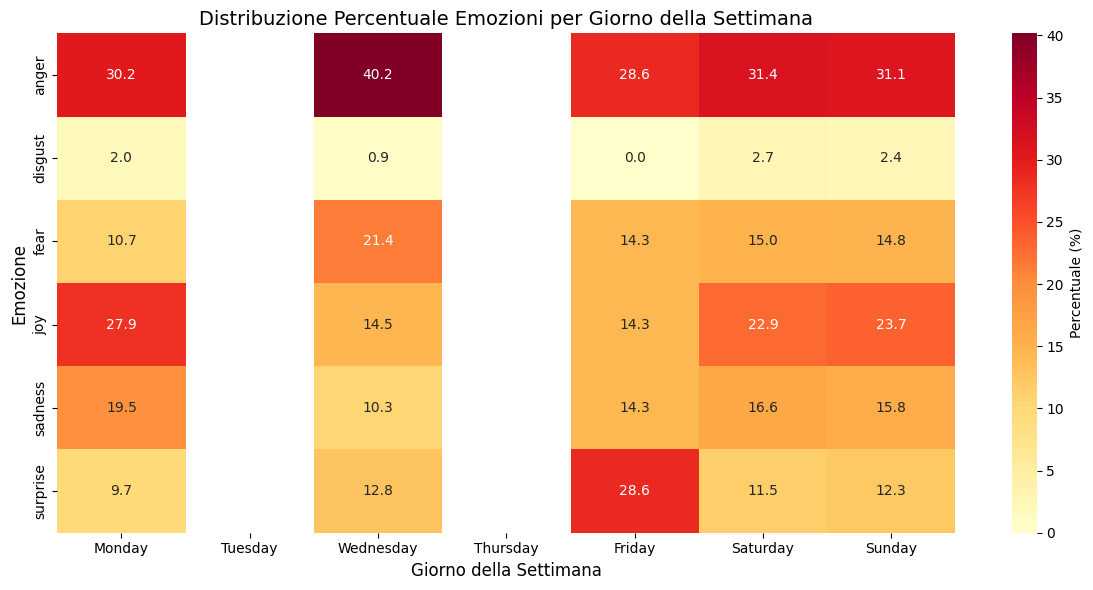

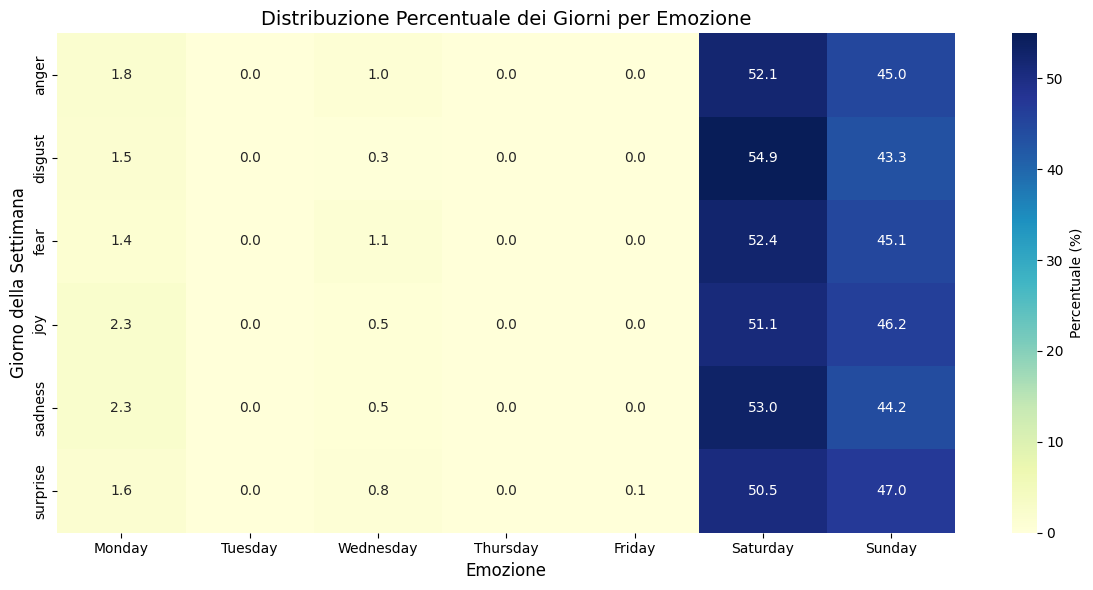

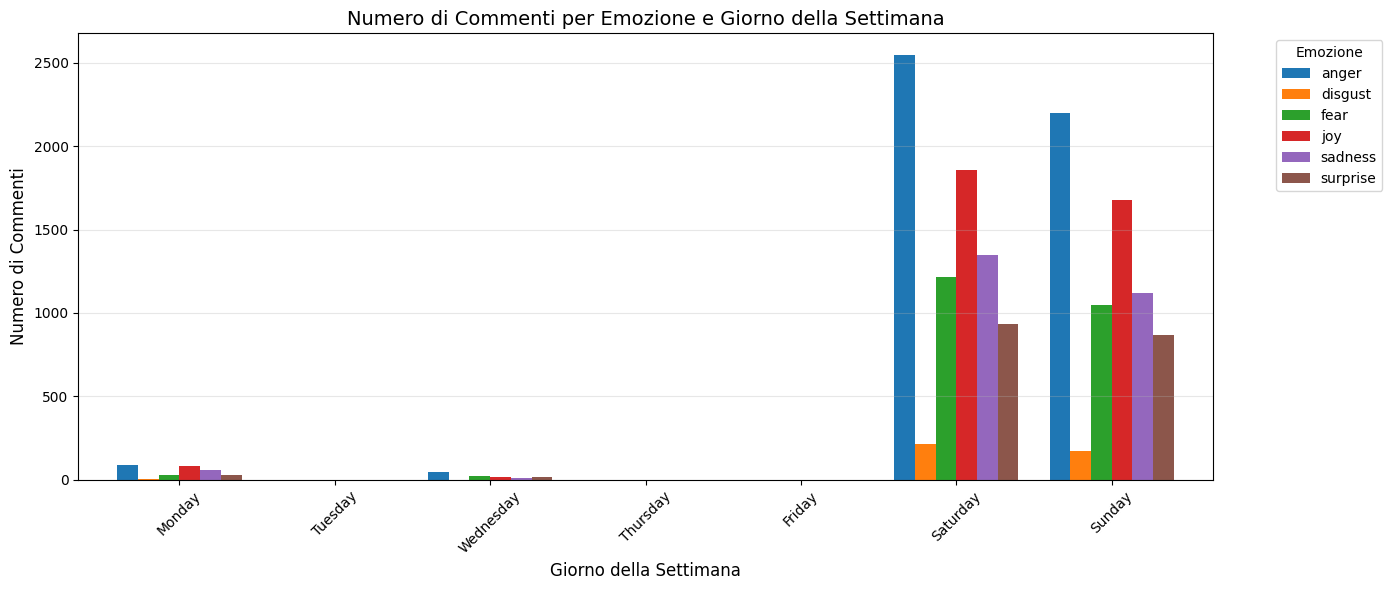

In [ ]:
# Ordina i giorni della settimana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_no_neutral['day_of_week'] = pd.Categorical(df_no_neutral['day_of_week'], categories=day_order, ordered=True)

print("\n=== DISTRIBUZIONE EMOZIONI PER GIORNO DELLA SETTIMANA ===")
emotions_by_day = df_no_neutral.groupby(['day_of_week', 'emotion']).size().unstack(fill_value=0)
print(emotions_by_day)

# Heatmap
plt.figure(figsize=(12, 6))
emotions_by_day_pct = emotions_by_day.div(emotions_by_day.sum(axis=1), axis=0) * 100
sns.heatmap(emotions_by_day_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Percentuale (%)'})
plt.title('Distribuzione Percentuale Emozioni per Giorno della Settimana', fontsize=14)
plt.xlabel('Giorno della Settimana', fontsize=12)
plt.ylabel('Emozione', fontsize=12)
plt.tight_layout()
plt.show()

# Heatmap 2
plt.figure(figsize=(12, 6))
emotions_by_day_pct = emotions_by_day.div(emotions_by_day.sum(axis=0), axis=1) * 100
sns.heatmap(emotions_by_day_pct.T, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Percentuale (%)'})
plt.title('Distribuzione Percentuale dei Giorni per Emozione', fontsize=14)
plt.xlabel('Emozione', fontsize=12)
plt.ylabel('Giorno della Settimana', fontsize=12)
plt.tight_layout()
plt.show()

# Grafico a barre raggruppate
emotions_by_day.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Numero di Commenti per Emozione e Giorno della Settimana', fontsize=14)
plt.xlabel('Giorno della Settimana', fontsize=12)
plt.ylabel('Numero di Commenti', fontsize=12)
plt.legend(title='Emozione', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 8.3 Analizziamo i 10 giorni con più attività emotiva, è successo qualcosa in quel periodo? Quali sono le emozioni più elevate per i primi 3 giorni?


=== TOP 10 GIORNI CON PIÙ ATTIVITÀ EMOTIVA ===
date
2025-05-31    865
2025-07-27    625
2025-02-02    583
2025-08-10    560
2025-09-13    483
2025-05-25    463
2025-08-03    437
2025-08-16    403
2025-06-07    389
2025-05-24    383
dtype: int64

=== DISTRIBUZIONE EMOZIONI NEI TOP 5 GIORNI PIÙ ATTIVI ===

2025-05-31:
emotion
anger       263
fear        185
joy         153
sadness     129
surprise    123
disgust      12
Name: count, dtype: int64

2025-07-27:
emotion
anger       216
joy         178
sadness      99
surprise     69
fear         54
disgust       9
Name: count, dtype: int64

2025-02-02:
emotion
fear        177
anger       112
sadness     107
joy         107
surprise     72
disgust       8
Name: count, dtype: int64


<Figure size 1500x600 with 0 Axes>

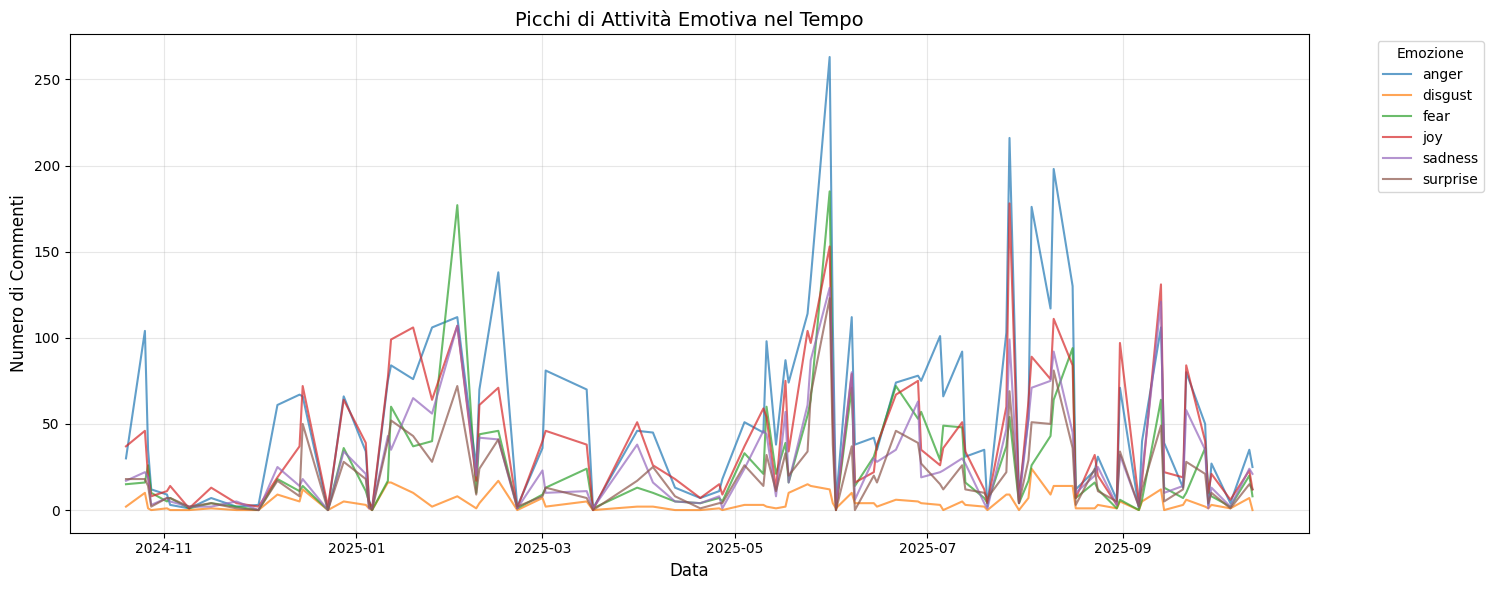

In [ ]:
# Identifica i giorni con più attività emotiva
print("\n=== TOP 10 GIORNI CON PIÙ ATTIVITÀ EMOTIVA ===")
daily_counts = df_no_neutral.groupby('date').size().sort_values(ascending=False)
print(daily_counts.head(10))

# Emozioni per i primi 3 giorni
top_days = daily_counts.head(3).index
print("\n=== DISTRIBUZIONE EMOZIONI NEI TOP 3 GIORNI PIÙ ATTIVI ===")
for day in top_days:
    print(f"\n{day}:")
    day_emotions = df_no_neutral[df_no_neutral['date'] == day]['emotion'].value_counts()
    print(day_emotions)

# Visualizza picchi emotivi
plt.figure(figsize=(15, 6))
daily_emotion_counts = df_no_neutral.groupby(['date', 'emotion']).size().unstack(fill_value=0)
daily_emotion_counts.plot(figsize=(15, 6), alpha=0.7)
plt.title('Picchi di Attività Emotiva nel Tempo', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Numero di Commenti', fontsize=12)
plt.legend(title='Emozione', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 8.4 L'intensità emotiva invece come varia nel corso del tempo?


=== INTENSITÀ EMOTIVA MEDIA NEL TEMPO ===
year_month
2024-10    0.759718
2024-11    0.792269
2024-12    0.773215
2025-01    0.764461
2025-02    0.778955
2025-03    0.760596
2025-04    0.761282
2025-05    0.779310
2025-06    0.778421
2025-07    0.766104
2025-08    0.772117
2025-09    0.759278
2025-10    0.771331
Freq: M, Name: emotion_score, dtype: float64


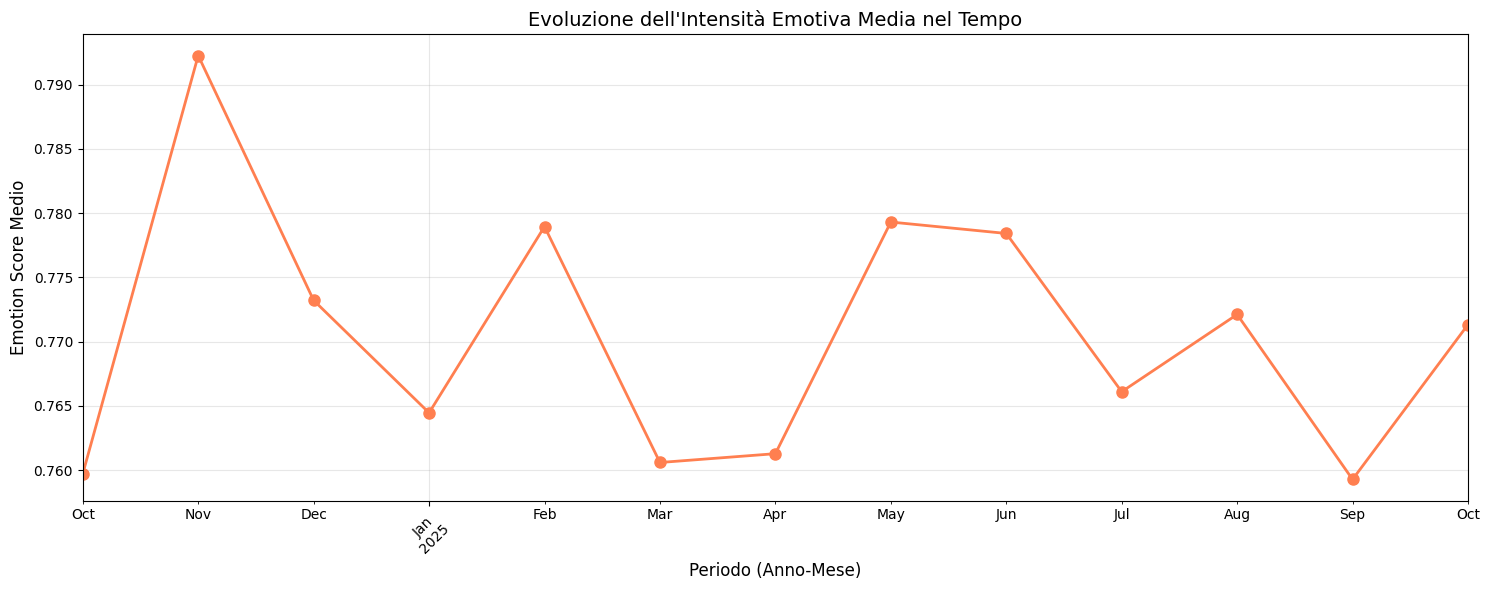

In [ ]:
# Intensità emotiva media nel tempo
print("\n=== INTENSITÀ EMOTIVA MEDIA NEL TEMPO ===")
intensity_by_month = df_no_neutral.groupby('year_month')['emotion_score'].mean()
print(intensity_by_month)

plt.figure(figsize=(15, 6))
intensity_by_month.plot(marker='o', linewidth=2, markersize=8, color='coral')
plt.title('Evoluzione dell\'Intensità Emotiva Media nel Tempo', fontsize=14)
plt.xlabel('Periodo (Anno-Mese)', fontsize=12)
plt.ylabel('Emotion Score Medio', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 9. Come sono distribuite le diverse emozioni nei vari macro-topic?


=== DISTRIBUZIONE EMOZIONI PER MACRO_TOPIC ===
emotion                               anger  disgust   fear    joy  sadness  \
macro_topic                                                                   
AGI e Sviluppo Tecnologico            31.86     2.84  12.46  23.77    17.44   
Impatto Socio-Economico e Governance  30.16     2.48  14.75  23.39    16.72   
Rischi, Etica e Sicurezza             32.62     2.04  19.60  22.00    12.96   

emotion                               surprise  
macro_topic                                     
AGI e Sviluppo Tecnologico               11.62  
Impatto Socio-Economico e Governance     12.51  
Rischi, Etica e Sicurezza                10.79  


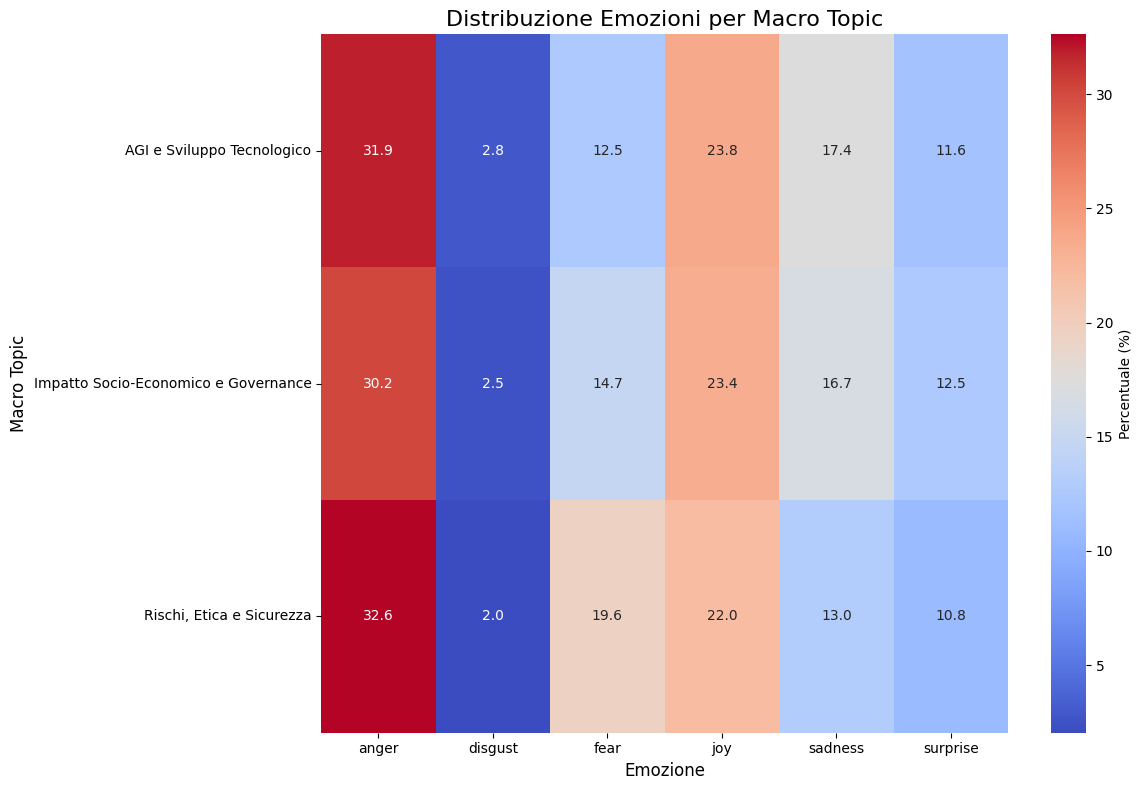


=== INTENSITÀ EMOTIVA MEDIA PER MACRO_TOPIC ===
                                       mean    std  count
macro_topic                                              
Rischi, Etica e Sicurezza             0.781  0.157   3087
Impatto Socio-Economico e Governance  0.771  0.157   6658
AGI e Sviluppo Tecnologico            0.767  0.155   5876


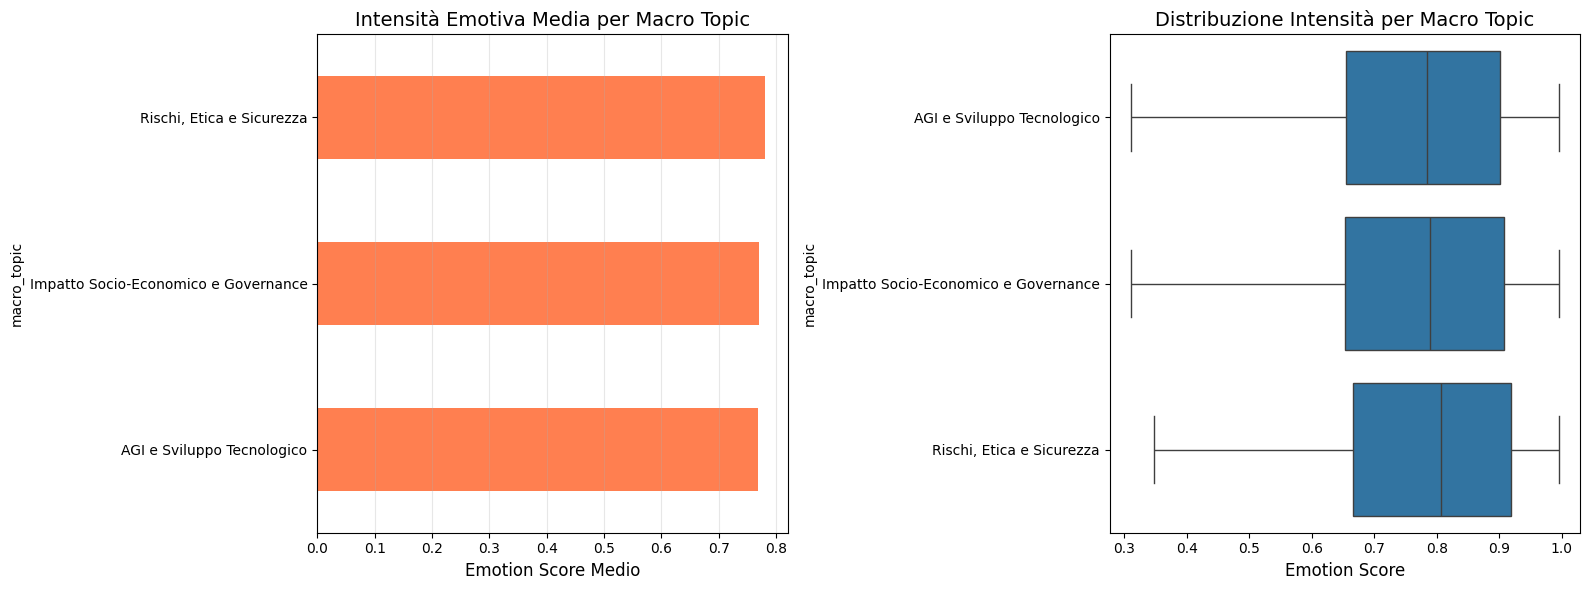

In [ ]:
print("\n=== DISTRIBUZIONE EMOZIONI PER MACRO_TOPIC ===")
emotion_by_macro = pd.crosstab(df_no_neutral['macro_topic'], 
                               df_no_neutral['emotion'], 
                               normalize='index') * 100
print(emotion_by_macro.round(2))

# Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(emotion_by_macro, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Percentuale (%)'})
plt.title('Distribuzione Emozioni per Macro Topic', fontsize=16)
plt.xlabel('Emozione', fontsize=12)
plt.ylabel('Macro Topic', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== INTENSITÀ EMOTIVA MEDIA PER MACRO_TOPIC ===")
intensity_by_macro = df_no_neutral.groupby('macro_topic')['emotion_score'].agg(['mean', 'std', 'count'])
print(intensity_by_macro.sort_values('mean', ascending=False).round(3))

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
intensity_by_macro['mean'].sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Intensità Emotiva Media per Macro Topic', fontsize=14)
axes[0].set_xlabel('Emotion Score Medio', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
sns.boxplot(data=df_no_neutral, y='macro_topic', x='emotion_score', ax=axes[1])
axes[1].set_title('Distribuzione Intensità per Macro Topic', fontsize=14)
axes[1].set_xlabel('Emotion Score', fontsize=12)
plt.tight_layout()
plt.show()

#### 10. Gli autori noti e non noti mostrano differenze significative nella distribuzione delle emozioni espresse?


=== CONFRONTO EMOZIONI: AUTORI NOTI vs NON NOTI ===
emotion          anger  disgust   fear    joy  sadness  surprise
Autore Non Noto  33.49     2.35  12.05  24.57    17.84      9.70
Autore Noto      31.19     2.54  14.96  23.20    16.18     11.93


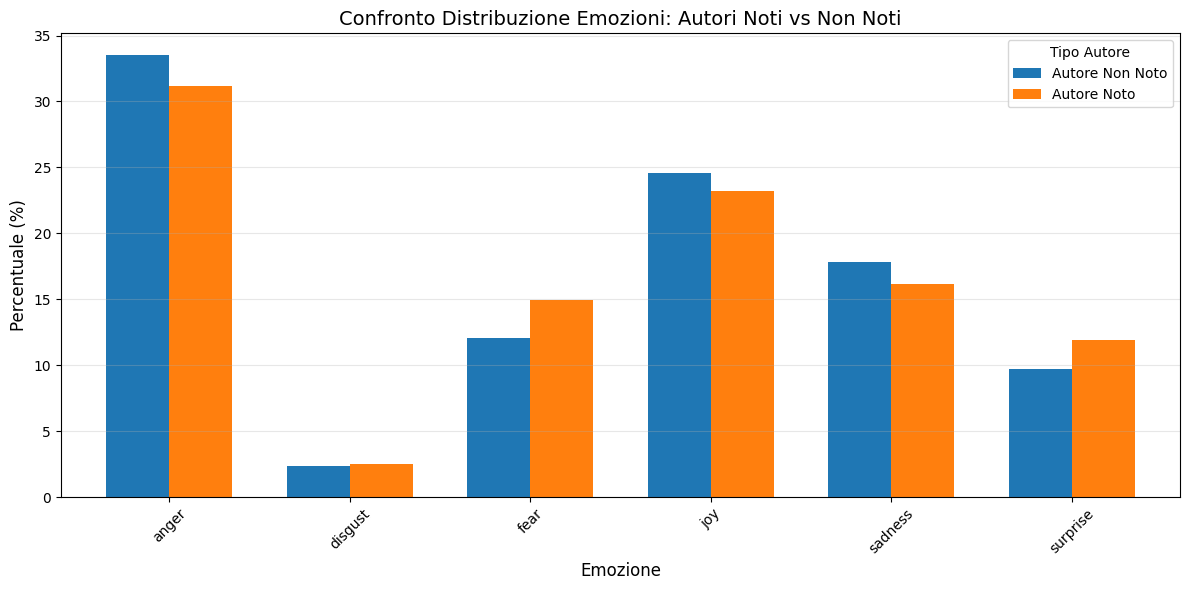


=== TEST CHI-QUADRATO ===
Chi2: 8.7262
P-value: 0.1205
La differenza è statisticamente significativa: NO


In [ ]:
print("\n=== CONFRONTO EMOZIONI: AUTORI NOTI vs NON NOTI ===")
author_comparison = pd.crosstab(df_no_neutral['is_author_known'], 
                                df_no_neutral['emotion'], 
                                normalize='index') * 100
author_comparison.index = ['Autore Non Noto', 'Autore Noto']
print(author_comparison.round(2))

# BarPlot
author_comparison.T.plot(kind='bar', figsize=(12, 6), width=0.7)
plt.title('Confronto Distribuzione Emozioni: Autori Noti vs Non Noti', fontsize=14)
plt.xlabel('Emozione', fontsize=12)
plt.ylabel('Percentuale (%)', fontsize=12)
plt.legend(title='Tipo Autore')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Test statistico (Chi-quadrato) 
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_no_neutral['is_author_known'], df_no_neutral['emotion'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n=== TEST CHI-QUADRATO ===")
print(f"Chi2: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"La differenza è statisticamente significativa: {'SÌ' if p_value < 0.05 else 'NO'}")

#### 11. Esiste una relazione tra il livello di engagement dei commenti e la distribuzione delle emozioni?


=== CONFRONTO EMOZIONI: POST AD ALTO vs BASSO ENGAGEMENT ===
emotion           anger  disgust   fear    joy  sadness  surprise
Basso Engagement  32.14     2.05  15.40  23.67    15.44     11.30
Alto Engagement   30.85     2.78  14.56  23.04    16.67     12.11


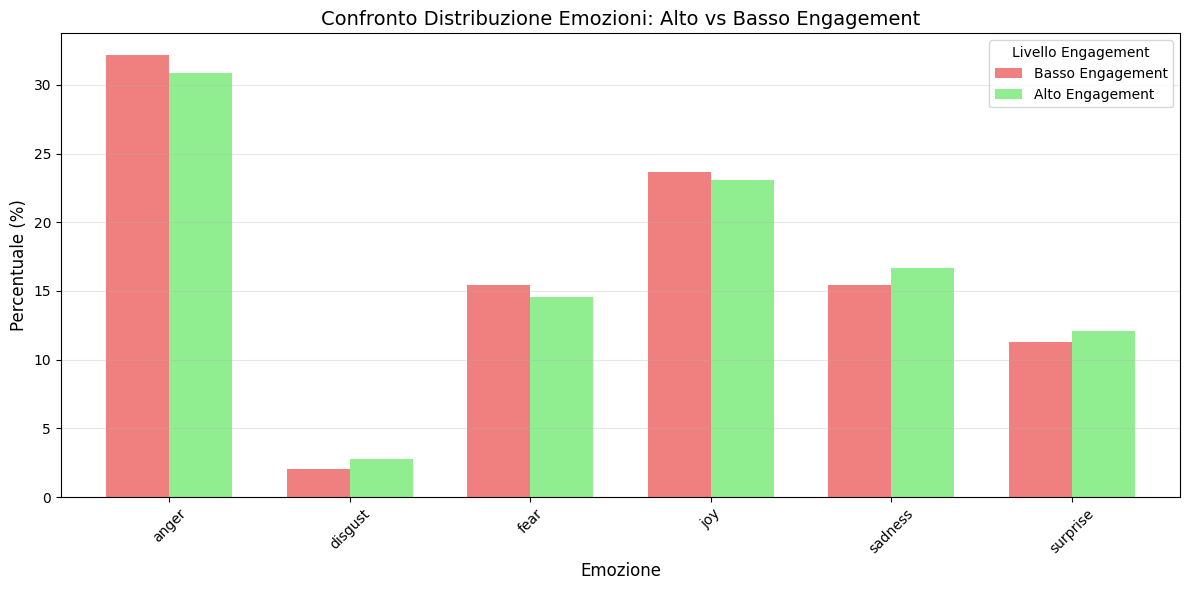


=== TEST CHI-QUADRATO ===
Chi2: 16.6634
P-value: 0.0052
La differenza è statisticamente significativa: SÌ


In [ ]:
median_score = df_no_neutral['score_comment'].median()
df_no_neutral['high_engagement'] = df_no_neutral['score_comment'] >= median_score

print("\n=== CONFRONTO EMOZIONI: POST AD ALTO vs BASSO ENGAGEMENT ===")
engagement_comparison = pd.crosstab(df_no_neutral['high_engagement'], 
                                    df_no_neutral['emotion'], 
                                    normalize='index') * 100
engagement_comparison.index = ['Basso Engagement', 'Alto Engagement']
print(engagement_comparison.round(2))

# Visualizzazione
engagement_comparison.T.plot(kind='bar', figsize=(12, 6), width=0.7, color=['lightcoral', 'lightgreen'])
plt.title('Confronto Distribuzione Emozioni: Alto vs Basso Engagement', fontsize=14)
plt.xlabel('Emozione', fontsize=12)
plt.ylabel('Percentuale (%)', fontsize=12)
plt.legend(title='Livello Engagement')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Test statistico (Chi-quadrato) 
contingency_table = pd.crosstab(df_no_neutral['high_engagement'], df_no_neutral['emotion'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n=== TEST CHI-QUADRATO ===")
print(f"Chi2: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"La differenza è statisticamente significativa: {'SÌ' if p_value < 0.05 else 'NO'}")

#### 12. Analisi generali dei vari topic. Quali topic generano maggiore paura / gioia ...?

In [ ]:
for emotion in df_no_neutral['emotion'].unique():
    print(f"\n{'='*60}")
    print(f"EMOZIONE: {emotion.upper()}")
    print('='*60)
    
    emotion_data = df_no_neutral[df_no_neutral['emotion'] == emotion]
    
    # macro_topic per questa emozione
    print(f"\nTop Macro Topics che generano {emotion}:")
    top_macro = emotion_data['macro_topic'].value_counts().head(5)
    for topic, count in top_macro.items():
        pct = (count / len(emotion_data)) * 100
        print(f"  • {topic}: {count} ({pct:.1f}%)")
    
    # search_topic per questa emozione
    print(f"\nTop Search Topics che generano {emotion}:")
    top_search = emotion_data['search_topic'].value_counts().head(5)
    for topic, count in top_search.items():
        pct = (count / len(emotion_data)) * 100
        print(f"  • {topic}: {count} ({pct:.1f}%)")
    
    # Intensità media
    avg_intensity = emotion_data['emotion_score'].mean()
    print(f"\nIntensità media per {emotion}: {avg_intensity:.3f}")


EMOZIONE: ANGER

Top Macro Topics che generano anger:
  • Impatto Socio-Economico e Governance: 2008 (41.1%)
  • AGI e Sviluppo Tecnologico: 1872 (38.3%)
  • Rischi, Etica e Sicurezza: 1007 (20.6%)

Top Search Topics che generano anger:
  • AGI e Sviluppo Tecnologico: 1872 (38.3%)
  • Impatto sul Lavoro e AI: 1256 (25.7%)
  • Regolamentazione e AI: 752 (15.4%)
  • Sicurezza e AI: 686 (14.0%)
  • Etica e AI: 321 (6.6%)

Intensità media per anger: 0.738

EMOZIONE: JOY

Top Macro Topics che generano joy:
  • Impatto Socio-Economico e Governance: 1557 (42.9%)
  • AGI e Sviluppo Tecnologico: 1397 (38.5%)
  • Rischi, Etica e Sicurezza: 679 (18.7%)

Top Search Topics che generano joy:
  • AGI e Sviluppo Tecnologico: 1397 (38.5%)
  • Impatto sul Lavoro e AI: 1101 (30.3%)
  • Regolamentazione e AI: 456 (12.6%)
  • Sicurezza e AI: 447 (12.3%)
  • Etica e AI: 232 (6.4%)

Intensità media per joy: 0.783

EMOZIONE: SURPRISE

Top Macro Topics che generano surprise:
  • Impatto Socio-Economico e Gove

#### 13. AGGIUNGERE UN COMANDO PER VEDERE I PRIMI 3 COMMENTI PER OGNI EMOZIONI PER OGNI MACRO TOPIC COSI DA POTER CITARLI NELLA TESI!

# Topic modeling

In [72]:
!pip3 install bertopic sentence-transformers umap-learn hdbscan

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [73]:
!pip3 install --upgrade nbformat plotly kaleido

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [74]:
percorso_file = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/Reddit_Post_ChatGPT.csv'
df_post = pd.read_csv(percorso_file)

In [75]:
df_post['Title'] = df_post['Title'].str.lower()
df_post['Title'] = df_post['Title'].apply(preprocess_spacy)
print(df_post['Title'].head(5))

0    murdered insurance ceo deployed ai automatical...
1    white house accused chatgpt create tariff plan...
2    bernie sanders says ai makes productive day wo...
3    elon tweaked grok grok mechahitler funny actua...
4       ai experts return china stunned grid weak race
Name: Title, dtype: object


In [76]:
df_unique = df_post.drop_duplicates(subset=['post_id'], keep='first')
print(f"Titoli originali: {len(df_post)}")
print(f"Titoli unici: {len(df_unique)}")

Titoli originali: 250
Titoli unici: 209


In [77]:
ids_to_remove = [
    "1keyhgj", "1k3f8q4", "1h3onlx", "1kspqmc", "1mhegmw", "1iqyy19", "1h69vuu",
    "1k536ei", "1hkwrh1", "1m6jhv6", "1kmputa", "1l5s4lg", "1jz39uz", "1hetvh7",
    "1hhisri", "1mxvwu2", "1kds8xx", "1n3zrgc", "1ltmp2c", "1m84efp", "1muksse",
    "1kmisjx", "1nlwi9i", "1jv3ga6", "1jr7l2a", "1hvthra", "1jfe66a", "1ncx1qm"
]

df_unique = df_unique[~df_unique['post_id'].isin(ids_to_remove)]

In [78]:
print(f"Titoli unici: {len(df_unique)}")

Titoli unici: 181


In [79]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP

# Setup modello
embedding_model = SentenceTransformer('all-mpnet-base-v2', device='cpu')

# Aggiungi solo il seed per riproducibilità
umap_model = UMAP(random_state=116)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,  # Aggiungi questa riga
    min_topic_size=5,
    nr_topics="auto",
    language="english",
    verbose=True
)

# Fit (UNA SOLA VOLTA - quello che trova 8 topic)
topics, probs = topic_model.fit_transform(df_unique['Title'])

# Assegna solo il topic
df_unique['topic'] = topics

print(f"\n✅ Topic assegnati!")
print(f"Titoli: {len(df_unique)}")
print(f"Topic trovati: {len(set(topics)) - 1}")  # -1 per escludere outlier

# Info sui topic
topic_info = topic_model.get_topic_info()
print(f"\n📋 TOPIC:")
print(topic_info[['Topic', 'Count', 'Name']])

/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-05 18:11:58,810 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 6/6 [00:02<00:00,  2.05it/s]
2025-12-05 18:12:01,810 - BERTopic - Embedding - Completed ✓
2025-12-05 18:12:01,810 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-05 18:12:06,903 - BERTopic - Dimensionality - Completed ✓
2025-12-05 18:12:06,904 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-05 18:12:06,916 - BERTopic - Cluster - Completed ✓
2025-12-05 18:12:06,917 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-05 18:12:06,938 - BERTopic - Representation - Completed ✓
2025-12-05 18:12:06,938 - BERTopic - To


✅ Topic assegnati!
Titoli: 181
Topic trovati: 7

📋 TOPIC:
   Topic  Count                                       Name
0     -1     58                -1_ai_chatgpt_future_people
1      0     59                         0_jobs_ai_job_says
2      1     22                   1_safety_ai_google_world
3      2     15       2_regulation_regulations_house_state
4      3     10              3_models_ethical_human_ethics
5      4      7                  4_openai_agi_training_law
6      5      5                 5_china_global_world_warns
7      6      5  6_understand_thinks_godfather_researchers


In [80]:
# Info completa su tutti i topic
topic_info = topic_model.get_topic_info()
print(topic_info)

# Quanti titoli per ogni topic?
print("\n📊 DISTRIBUZIONE TOPIC:")
print(df_unique['topic'].value_counts().sort_index())

   Topic  Count                                       Name  \
0     -1     58                -1_ai_chatgpt_future_people   
1      0     59                         0_jobs_ai_job_says   
2      1     22                   1_safety_ai_google_world   
3      2     15       2_regulation_regulations_house_state   
4      3     10              3_models_ethical_human_ethics   
5      4      7                  4_openai_agi_training_law   
6      5      5                 5_china_global_world_warns   
7      6      5  6_understand_thinks_godfather_researchers   

                                      Representation  \
0  [ai, chatgpt, future, people, generated, bubbl...   
1  [jobs, ai, job, says, work, need, gen, entry, ...   
2  [safety, ai, google, world, says, risk, tech, ...   
3  [regulation, regulations, house, state, bill, ...   
4  [models, ethical, human, ethics, ai, organizat...   
5  [openai, agi, training, law, manipulation, bil...   
6  [china, global, world, warns, premier, box, co

In [81]:
# Dizionario con le tue etichette
topic_labels = {
    -1: "Discussioni generali sull'IA",
    0: "Impatto dell'IA nel mondo del lavoro e nell'occupazione",
    1: "Sicurezza globale dell'IA e il ruolo di Google",
    2: "Regolamentazione e governance dell'IA",
    3: "Etica e sviluppi di modelli IA responsabili",
    4: "OpenAI: Addestramento dei dati e implicazioni legali",
    5: "Geopolitica dell'IA, il ruolo della cina",
    6: "L'IA è in grado di pensare e comprendere automaticamente?",
}

# Metodo 1: Aggiorna direttamente nel modello BERTopic
topic_model.set_topic_labels(topic_labels)

# Metodo 2: Aggiungi colonna al dataframe
df_unique['topic_label'] = df_unique['topic'].map(topic_labels)

# Verifica
print(df_unique[['Title', 'topic', 'topic_label']].head(10))

                                                Title  topic  \
0   murdered insurance ceo deployed ai automatical...     -1   
1   white house accused chatgpt create tariff plan...     -1   
2   bernie sanders says ai makes productive day wo...      0   
3   elon tweaked grok grok mechahitler funny actua...     -1   
4      ai experts return china stunned grid weak race      5   
6   zuckerberg announces layoffs saying coding job...      0   
8   mark zuckerberg vision future friends ai owned...     -1   
10  ai job interviews candidates risk staying unem...      0   
11  ai breaking entry level jobs gen z workers nee...      0   
12  ai breaking entry level jobs gen z workers nee...      0   

                                          topic_label  
0                        Discussioni generali sull'IA  
1                        Discussioni generali sull'IA  
2   Impatto dell'IA nel mondo del lavoro e nell'oc...  
3                        Discussioni generali sull'IA  
4            Ge

In [82]:
# Info topic con nuove etichette
topic_info = topic_model.get_topic_info()
print("\n📋 TOPIC CON ETICHETTE PERSONALIZZATE:\n")
print(topic_info[['Topic', 'Count', 'Name', 'CustomName']])

# Distribuzione con etichette
print("\n📊 DISTRIBUZIONE TOPIC:\n")
distribution = df_unique['topic_label'].value_counts()
for label, count in distribution.items():
    percentage = (count / len(df_unique)) * 100
    print(f"{label}: {count} titoli ({percentage:.1f}%)")


📋 TOPIC CON ETICHETTE PERSONALIZZATE:

   Topic  Count                                       Name  \
0     -1     58                -1_ai_chatgpt_future_people   
1      0     59                         0_jobs_ai_job_says   
2      1     22                   1_safety_ai_google_world   
3      2     15       2_regulation_regulations_house_state   
4      3     10              3_models_ethical_human_ethics   
5      4      7                  4_openai_agi_training_law   
6      5      5                 5_china_global_world_warns   
7      6      5  6_understand_thinks_godfather_researchers   

                                          CustomName  
0                       Discussioni generali sull'IA  
1  Impatto dell'IA nel mondo del lavoro e nell'oc...  
2     Sicurezza globale dell'IA e il ruolo di Google  
3              Regolamentazione e governance dell'IA  
4        Etica e sviluppi di modelli IA responsabili  
5  OpenAI: Addestramento dei dati e implicazioni ...  
6           Geop

In [83]:
# Top 10-15 parole per ogni topic con score
print("\n🔑 PAROLE CHIAVE PER TOPIC:\n")
for topic_id in range(7):
    print(f"{'='*60}")
    print(f"TOPIC {topic_id}")
    print(f"{'='*60}")
    
    # Ottieni le top 15 parole con il loro score c-TF-IDF
    words = topic_model.get_topic(topic_id)
    
    if words:
        for word, score in words[:10]:
            print(f"  {word:20s} | {score:.4f}")
    print()


🔑 PAROLE CHIAVE PER TOPIC:

TOPIC 0
  jobs                 | 0.0886
  ai                   | 0.0761
  job                  | 0.0513
  says                 | 0.0406
  work                 | 0.0374
  need                 | 0.0318
  gen                  | 0.0312
  entry                | 0.0312
  humans               | 0.0309
  level                | 0.0300

TOPIC 1
  safety               | 0.0849
  ai                   | 0.0826
  google               | 0.0620
  world                | 0.0449
  says                 | 0.0406
  risk                 | 0.0371
  tech                 | 0.0360
  systems              | 0.0360
  vulnerability        | 0.0319
  kill                 | 0.0319

TOPIC 2
  regulation           | 0.0980
  regulations          | 0.0925
  house                | 0.0865
  state                | 0.0805
  bill                 | 0.0805
  ai                   | 0.0790
  companies            | 0.0692
  act                  | 0.0678
  doge                 | 0.0678
  plan           

In [84]:
# I titoli più rappresentativi di ogni topic
print("\n📄 TITOLI PIÙ RAPPRESENTATIVI:\n")
for topic_id in range(7):
    print(f"{'='*60}")
    print(f"TOPIC {topic_id}")
    print(f"{'='*60}")
    
    # Ottieni i documenti più rappresentativi (passa anche i docs originali)
    representative_docs = topic_model.get_representative_docs(topic_id)
    
    # Se None, prendi manualmente i titoli del topic
    if representative_docs is None:
        # Fallback: prendi i primi 3 titoli del topic
        topic_titles = df_unique[df_unique['topic'] == topic_id]['Title'].head(3)
        representative_docs = topic_titles.tolist()
    
    for i, doc in enumerate(representative_docs, 1):
        print(f"{i}. {doc}")
    print()


📄 TITOLI PIÙ RAPPRESENTATIVI:

TOPIC 0
1. ai breaking entry level jobs gen z workers need launch careers linkedin exec warns likened disruption decline manufacturing
2. dario amodei says stop sugar coating coming years ai wipe entry level white collar jobs lawmakers believe ceos afraid talk workers wo realize risks hits
3. ai breaking entry level jobs gen z workers need launch careers linkedin exec warns

TOPIC 1
1. protesters accuse google breaking promises ai safety ai companies regulated sandwich shops
2. google claims world ai finds day security vulnerability ai agent discovered previously unknown zero day exploitable memory safety vulnerability widely real world software
3. google calls urgent agi safety planning better human level ai agi experts horizon figuring systems running wild google argues

TOPIC 2
1. ted cruz new bill let ai companies set rules sandbox act let companies request exemptions regulation ai products services let white house override agencies
2. doge ai tool m

In [85]:
# Salva le visualizzazioni come HTML
try:
    # Mappa interattiva dei topic
    fig1 = topic_model.visualize_topics()
    fig1.write_html("topic_map.html")
    print("✅ Salvato: topic_map.html")
    
    # Barchart con parole chiave
    fig2 = topic_model.visualize_barchart(top_n_topics=7)
    fig2.write_html("topic_keywords.html")
    print("✅ Salvato: topic_keywords.html")
    
    # Heatmap similarità tra topic
    fig3 = topic_model.visualize_heatmap()
    fig3.write_html("topic_similarity.html")
    print("✅ Salvato: topic_similarity.html")
    
    # Gerarchia dei topic
    fig4 = topic_model.visualize_hierarchy()
    fig4.write_html("topic_hierarchy.html")
    print("✅ Salvato: topic_hierarchy.html")
    
    print("\n✅ Apri i file HTML nel browser per vedere le visualizzazioni!")
    
except Exception as e:
    print(f"⚠️ Errore visualizzazioni: {e}")

✅ Salvato: topic_map.html
✅ Salvato: topic_keywords.html
✅ Salvato: topic_similarity.html
✅ Salvato: topic_hierarchy.html

✅ Apri i file HTML nel browser per vedere le visualizzazioni!


In [86]:
percorso_file = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/RedditSentimentFullAnalysis.csv'
df_merged = pd.read_csv(percorso_file)

In [87]:
# 1. Aggiungi topic_label a df_unique
topic_labels = {
    -1: "Discussioni generali sull'IA",
    0: "Impatto dell'IA nel mondo del lavoro e nell'occupazione",
    1: "Sicurezza globale dell'IA e il ruolo di Google",
    2: "Regolamentazione e governance dell'IA",
    3: "Etica e sviluppi di modelli IA responsabili",
    4: "OpenAI: Addestramento dei dati e implicazioni legali",
    5: "Geopolitica dell'IA, il ruolo della cina",
    6: "L'IA è in grado di pensare e comprendere automaticamente?",
}
df_unique['topic_label'] = df_unique['topic'].map(topic_labels)

# 2. Rimuovi colonne topic esistenti in df_merged (se ci sono)
cols_to_drop = [col for col in df_merged.columns if 'topic' in col.lower()]
if cols_to_drop:
    print(f"Rimozione colonne esistenti: {cols_to_drop}")
    df_merged = df_merged.drop(columns=cols_to_drop)

# 3. Assicurati che post_id sia dello stesso tipo
df_unique['post_id'] = df_unique['post_id'].astype(str)
df_merged['post_id'] = df_merged['post_id'].astype(str)

# 4. Merge
print(f"\nPrima del merge:")
print(f"  df_merged: {len(df_merged)} righe")
print(f"  df_unique: {len(df_unique)} righe con topic")

df_merged = df_merged.merge(
    df_unique[['post_id', 'topic', 'topic_label']],
    on='post_id',
    how='left'
)

# 5. Verifica risultato
print(f"\n✅ Merge completato!")
print(f"Righe totali: {len(df_merged)}")
print(f"Righe con topic: {df_merged['topic'].notna().sum()}")
print(f"Righe senza topic (NaN): {df_merged['topic'].isna().sum()}")

# 6. Mostra esempi
print("\nEsempi:")
print(df_merged[['post_id', 'topic', 'topic_label']].head(10))

# 7. Verifica che le colonne esistano ora
print(f"\nColonne in df_merged: {df_merged.columns.tolist()}")

Rimozione colonne esistenti: ['search_topic', 'macro_topic']

Prima del merge:
  df_merged: 52139 righe
  df_unique: 181 righe con topic

✅ Merge completato!
Righe totali: 52139
Righe con topic: 52139
Righe senza topic (NaN): 0

Esempi:
   post_id  topic                                     topic_label
0  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
1  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
2  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
3  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
4  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
5  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
6  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
7  1g8134i      1  Sicurezza globale dell'IA e il ruolo di Google
8  1g85htv     -1                    Discussioni generali sull'IA
9  1g85htv     -1                    Discussioni generali sull'IA

Colonne in df_merged: ['post_id', 'c

In [88]:
df_merged

,post_id,comment_id,author,body,score_comment,Title,score_post,UpVote_Ratio,Num_Comments,created_utc,body_len,word_count,avg_word_count,is_author_known,Sentiment,emotion,emotion_score,topic,topic_label
0,1g8134i,lsuq2vb,MetaKnowing,anthropic today announced sweeping update resp...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,1545,201,7.686567,1,1,fear,0.6532,1,Sicurezza globale dell'IA e il ruolo di Google
1,1g8134i,lsypkn5,BorderKeeper,headlines pop introductory minutes horror movi...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,140,26,5.384615,1,-1,fear,0.9927,1,Sicurezza globale dell'IA e il ruolo di Google
2,1g8134i,lsv3zpo,frankcast554,s great surely agi nt figure way,7,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,57,11,5.181818,1,1,sadness,0.3995,1,Sicurezza globale dell'IA e il ruolo di Google
3,1g8134i,lsxee20,2D-Renderman,thought called laws robotics,0,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,74,13,5.692308,1,0,neutral,0.5483,1,Sicurezza globale dell'IA e il ruolo di Google
4,1g8134i,lsyiu0x,FableFinale,asimov wrote extensively flawedthe issue entir...,4,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,206,36,5.722222,1,-1,neutral,0.5603,1,Sicurezza globale dell'IA e il ruolo di Google
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52134,1o4os6o,nj8mh6p,billdietrich1,tech billionaires intimidation m shocked shock...,9,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,115,18,6.388889,1,-1,surprise,0.9827,4,OpenAI: Addestramento dei dati e implicazioni ...
52135,1o4os6o,nj3jgye,FinnFarrow,nathan calvin general counsel encode small ai ...,36,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,748,69,10.840580,1,-1,fear,0.8986,4,OpenAI: Addestramento dei dati e implicazioni ...
52136,1o4os6o,nj3s13e,BomberRURP,company went congress said billions dollars wo...,124,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,174,31,5.612903,1,-1,fear,0.9349,4,OpenAI: Addestramento dei dati e implicazioni ...
52137,1o4os6o,njc49z1,Tinac4,sure mention sb musk muskaffiliated cover legi...,1,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,115,18,6.388889,1,1,neutral,0.9222,4,OpenAI: Addestramento dei dati e implicazioni ...


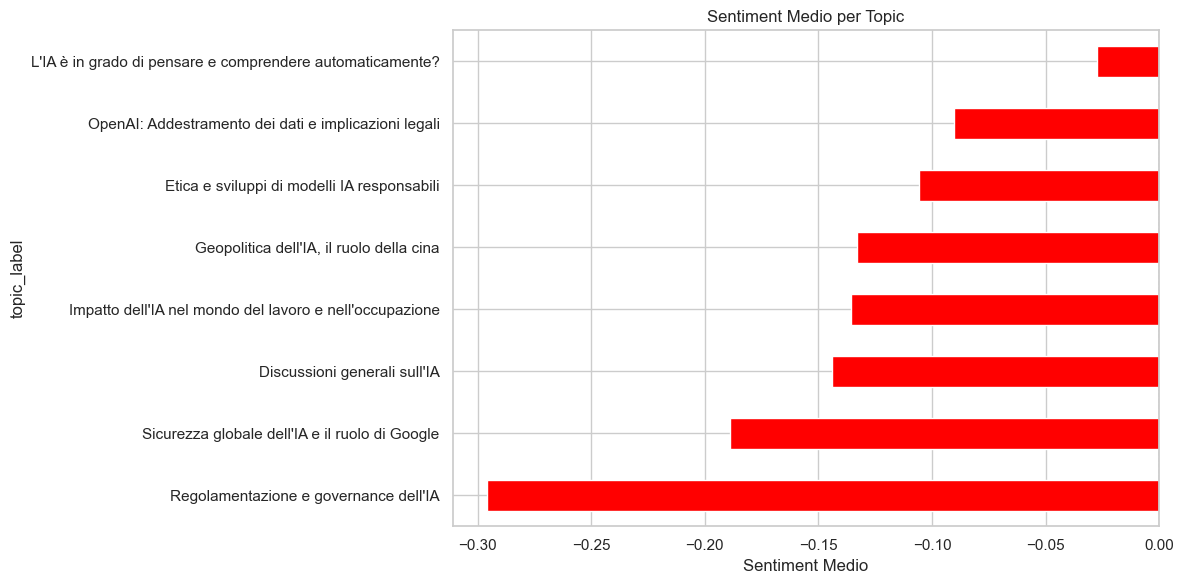

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment medio per topic
sentiment_by_topic = df_merged.groupby('topic_label')['Sentiment'].mean().sort_values()

# Visualizza
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in sentiment_by_topic.values]
sentiment_by_topic.plot(kind='barh', color=colors, ax=ax)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Sentiment Medio')
ax.set_title('Sentiment Medio per Topic')
plt.tight_layout()
plt.savefig('sentiment_per_topic.png', dpi=150)
plt.show()

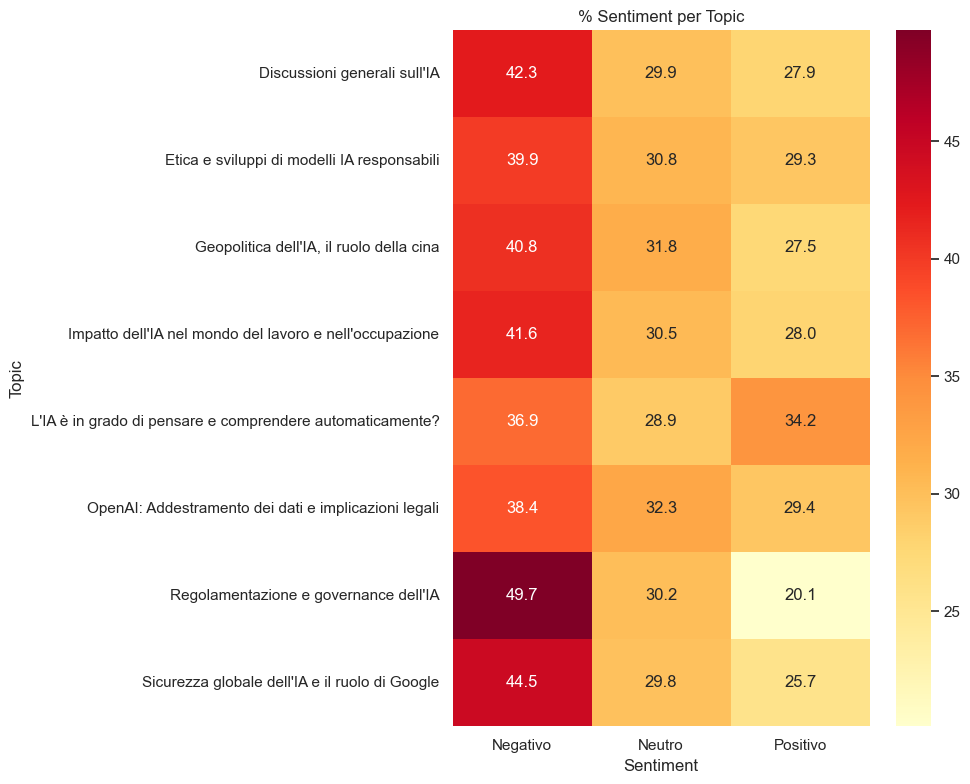

In [99]:
# Categorizza sentiment
def categorize_sentiment(score):
    if score > 0.05:
        return 'Positivo'
    elif score < -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

df_merged['sentiment_cat'] = df_merged['Sentiment'].apply(categorize_sentiment)

# Crosstab
heatmap_data = pd.crosstab(
    df_merged['topic_label'], 
    df_merged['sentiment_cat'], 
    normalize='index'  # Percentuali per riga
) * 100

# Visualizza
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data[['Negativo', 'Neutro', 'Positivo']], 
            annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('% Sentiment per Topic')
ax.set_ylabel('Topic')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.savefig('heatmap_topic_sentiment.png', dpi=150)
plt.show()

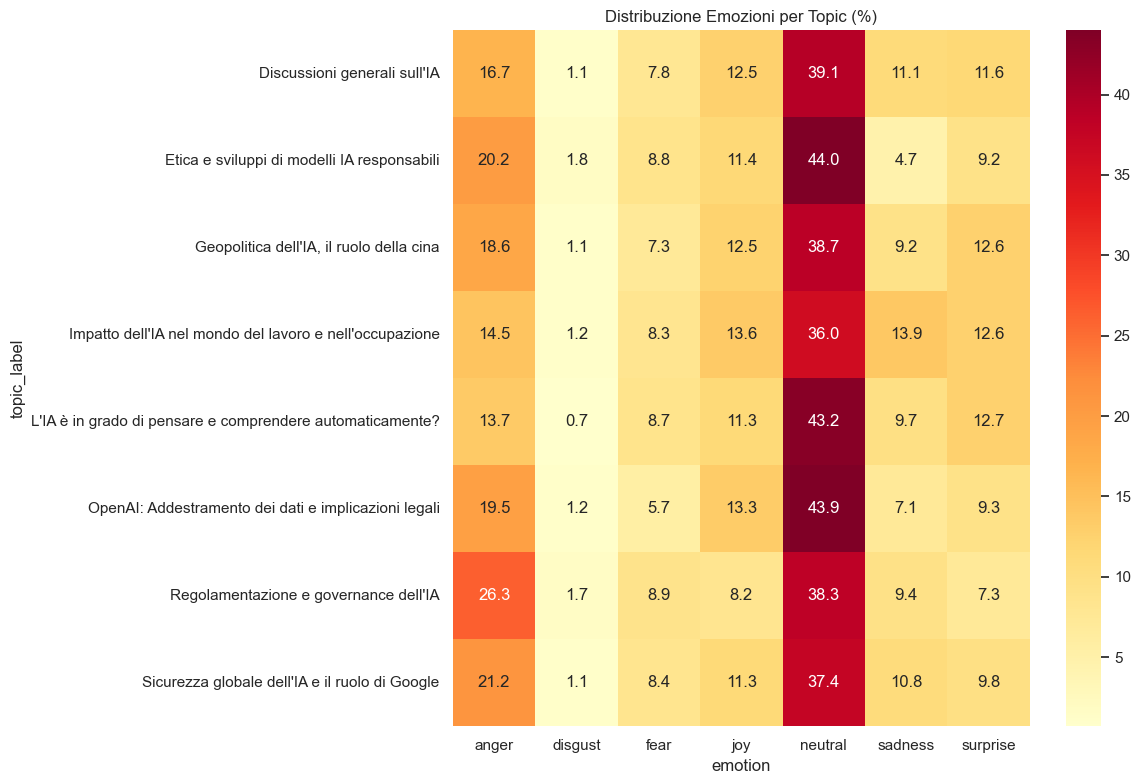

In [91]:
# Crosstab topic vs emotion
emotion_topic = pd.crosstab(
    df_merged['topic_label'], 
    df_merged['emotion'], 
    normalize='index'
) * 100

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(emotion_topic, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Distribuzione Emozioni per Topic (%)')
plt.tight_layout()
plt.savefig('heatmap_topic_emotion.png', dpi=150)
plt.show()

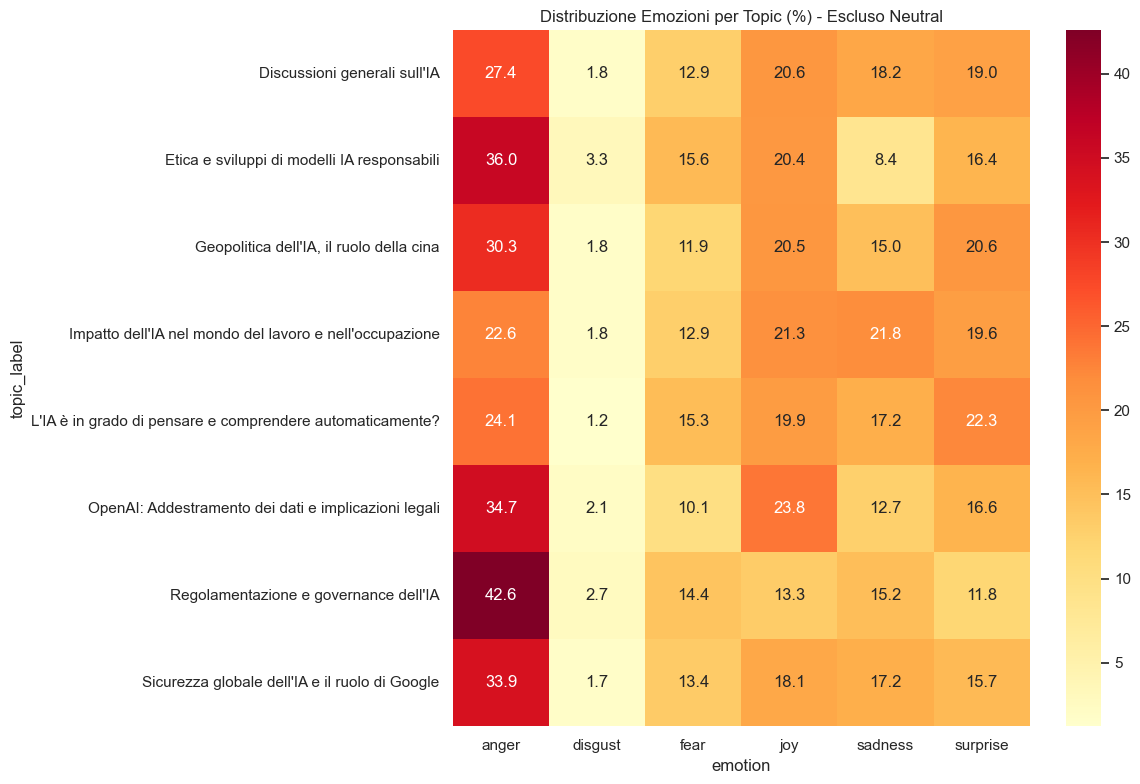

In [92]:
# Filtra i dati escludendo 'neutral'
df_no_neutral = df_merged[df_merged['emotion'] != 'neutral']

# Crosstab topic vs emotion (senza neutral)
emotion_topic = pd.crosstab(
    df_no_neutral['topic_label'], 
    df_no_neutral['emotion'], 
    normalize='index'
) * 100

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(emotion_topic, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Distribuzione Emozioni per Topic (%) - Escluso Neutral')
plt.tight_layout()
plt.savefig('heatmap_topic_emotion.png', dpi=150)
plt.show()

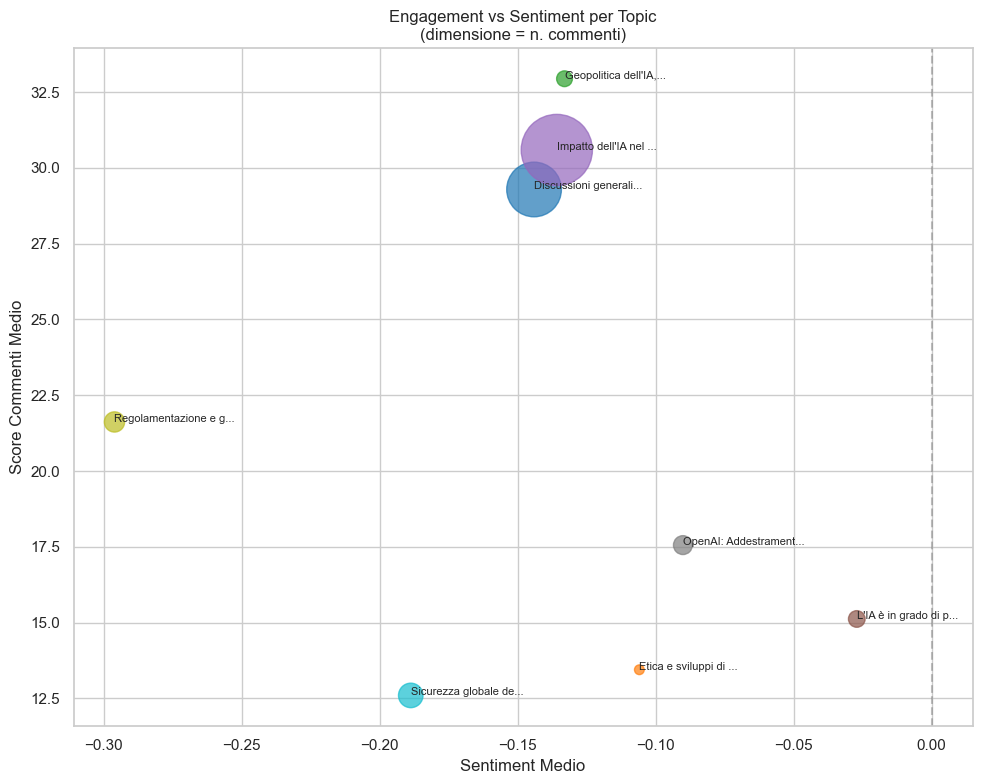

In [93]:
# Score medio vs Sentiment per topic
fig, ax = plt.subplots(figsize=(10, 8))

topic_data = df_merged.groupby('topic_label').agg({
    'Sentiment': 'mean',
    'score_comment': 'mean',
    'post_id': 'count'
}).rename(columns={'post_id': 'n_comments'})

scatter = ax.scatter(
    topic_data['Sentiment'], 
    topic_data['score_comment'],
    s=topic_data['n_comments'] / 10,  # Dimensione = n commenti
    alpha=0.7,
    c=range(len(topic_data)),
    cmap='tab10'
)

# Etichette
for idx, row in topic_data.iterrows():
    ax.annotate(idx[:20] + '...', (row['Sentiment'], row['score_comment']), fontsize=8)

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Sentiment Medio')
ax.set_ylabel('Score Commenti Medio')
ax.set_title('Engagement vs Sentiment per Topic\n(dimensione = n. commenti)')
plt.tight_layout()
plt.savefig('engagement_sentiment_topic.png', dpi=150)
plt.show()

In [94]:
# Report completo
report = df_merged.groupby('topic_label').agg({
    'Sentiment': ['mean', 'std'],
    'emotion': lambda x: x.mode().iloc[0] if len(x) > 0 else 'N/A',
    'score_comment': 'mean',
    'score_post': 'mean',
    'post_id': 'nunique',
    'comment_id': 'count'
}).round(3)

report.columns = ['Sentiment_Medio', 'Sentiment_Std', 'Emozione_Dominante', 
                  'Score_Commento_Medio', 'Score_Post_Medio', 
                  'N_Post_Unici', 'N_Commenti']

print("📊 REPORT COMPLETO TOPIC:\n")
print(report.to_string())

report.to_csv('report_topic_sentiment.csv')
print("\n✅ Salvato: report_topic_sentiment.csv")

📊 REPORT COMPLETO TOPIC:

                                                           Sentiment_Medio  Sentiment_Std Emozione_Dominante  Score_Commento_Medio  Score_Post_Medio  N_Post_Unici  N_Commenti
topic_label                                                                                                                                                                   
Discussioni generali sull'IA                                        -0.144          0.825            neutral                29.285         10420.358            58       15508
Etica e sviluppi di modelli IA responsabili                         -0.106          0.826            neutral                13.446          1391.485            10         491
Geopolitica dell'IA, il ruolo della cina                            -0.133          0.815            neutral                32.937          8809.086             5        1293
Impatto dell'IA nel mondo del lavoro e nell'occupazione             -0.136          0.823          

In [95]:
# Report completo (esclude 'neutral' per emozione dominante)
report = df_merged.groupby('topic_label').agg({
    'Sentiment': ['median', 'std'],
    'emotion': lambda x: x[x != 'neutral'].mode().iloc[0] if len(x[x != 'neutral']) > 0 else 'N/A',
    'score_comment': 'median',
    'score_post': 'median',
    'post_id': 'nunique',
    'comment_id': 'count'
}).round(3)

report.columns = ['Sentiment_Medio', 'Sentiment_Std', 'Emozione_Dominante', 
                  'Score_Commento_Medio', 'Score_Post_Medio', 
                  'N_Post_Unici', 'N_Commenti']

print("📊 REPORT COMPLETO TOPIC:\n")
print(report.to_string())

report.to_csv('report_topic_sentiment.csv')
print("\n✅ Salvato: report_topic_sentiment.csv")

📊 REPORT COMPLETO TOPIC:

                                                           Sentiment_Medio  Sentiment_Std Emozione_Dominante  Score_Commento_Medio  Score_Post_Medio  N_Post_Unici  N_Commenti
topic_label                                                                                                                                                                   
Discussioni generali sull'IA                                           0.0          0.825              anger                   2.0            7389.0            58       15508
Etica e sviluppi di modelli IA responsabili                            0.0          0.826              anger                   2.0             576.0            10         491
Geopolitica dell'IA, il ruolo della cina                               0.0          0.815              anger                   3.0            1293.0             5        1293
Impatto dell'IA nel mondo del lavoro e nell'occupazione                0.0          0.823          

In [96]:
df_merged.to_csv('RedditSentimentFullAnalysisTopic.csv', index=False)

In [97]:
df_merged

,post_id,comment_id,author,body,score_comment,Title,score_post,UpVote_Ratio,Num_Comments,created_utc,body_len,word_count,avg_word_count,is_author_known,Sentiment,emotion,emotion_score,topic,topic_label,sentiment_cat
0,1g8134i,lsuq2vb,MetaKnowing,anthropic today announced sweeping update resp...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,1545,201,7.686567,1,1,fear,0.6532,1,Sicurezza globale dell'IA e il ruolo di Google,Positivo
1,1g8134i,lsypkn5,BorderKeeper,headlines pop introductory minutes horror movi...,10,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,140,26,5.384615,1,-1,fear,0.9927,1,Sicurezza globale dell'IA e il ruolo di Google,Negativo
2,1g8134i,lsv3zpo,frankcast554,s great surely agi nt figure way,7,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,57,11,5.181818,1,1,sadness,0.3995,1,Sicurezza globale dell'IA e il ruolo di Google,Positivo
3,1g8134i,lsxee20,2D-Renderman,thought called laws robotics,0,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,74,13,5.692308,1,0,neutral,0.5483,1,Sicurezza globale dell'IA e il ruolo di Google,Neutro
4,1g8134i,lsyiu0x,FableFinale,asimov wrote extensively flawedthe issue entir...,4,Anthropic just made it harder for AI to go rog...,225,0.88,12,2024-10-20 15:19:59,206,36,5.722222,1,-1,neutral,0.5603,1,Sicurezza globale dell'IA e il ruolo di Google,Negativo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52134,1o4os6o,nj8mh6p,billdietrich1,tech billionaires intimidation m shocked shock...,9,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,115,18,6.388889,1,-1,surprise,0.9827,4,OpenAI: Addestramento dei dati e implicazioni ...,Negativo
52135,1o4os6o,nj3jgye,FinnFarrow,nathan calvin general counsel encode small ai ...,36,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,748,69,10.840580,1,-1,fear,0.8986,4,OpenAI: Addestramento dei dati e implicazioni ...,Negativo
52136,1o4os6o,nj3s13e,BomberRURP,company went congress said billions dollars wo...,124,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,174,31,5.612903,1,-1,fear,0.9349,4,OpenAI: Addestramento dei dati e implicazioni ...,Negativo
52137,1o4os6o,njc49z1,Tinac4,sure mention sb musk muskaffiliated cover legi...,1,A 3-person policy nonprofit that worked on Cal...,1484,0.98,19,2025-10-12 13:15:10,115,18,6.388889,1,1,neutral,0.9222,4,OpenAI: Addestramento dei dati e implicazioni ...,Positivo


# XAI

In [1]:
import pandas as pd

In [2]:
percorso_file = '/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/RedditSentimentFullAnalysisTopic.csv'
df_merged = pd.read_csv(percorso_file)

In [3]:
df_merged.columns

Index(['post_id', 'comment_id', 'author', 'body', 'score_comment', 'Title',
       'score_post', 'UpVote_Ratio', 'Num_Comments', 'created_utc', 'body_len',
       'word_count', 'avg_word_count', 'is_author_known', 'Sentiment',
       'emotion', 'emotion_score', 'sentiment_cat', 'topic', 'topic_label'],
      dtype='object')

In [4]:
!pip3 install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [5]:
!pip3 install shap

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [6]:
!pip3 install --upgrade lightgbm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Distribuzione score_comment:
count    52139.000000
mean        27.765070
std        234.506867
min       -263.000000
25%          1.000000
50%          2.000000
75%          8.000000
max      16727.000000
Name: score_comment, dtype: float64

Soglie definite:
  Basso: score 0-3
  Medio: score 4-10
  Alto:  score 11+

Distribuzione categorie:
score_category
basso    31344
alto     11391
medio     9404
Name: count, dtype: int64

Dataset: 52139 righe, 11 feature

RANDOM FOREST - GRID SEARCH CV

Parametri da testare:
  n_estimators: [200, 250, 300]
  max_depth: [20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  class_weight: ['balanced']

Totale combinazioni: 54
Inizio Grid Search (può richiedere qualche minuto)...

Fitting 5 folds for each of 54 candidates, totalling 270 fits

✓ Grid Search completata!

Migliori parametri Random Forest:
  class_weight: balanced
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Performance Random For

/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:47:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:47:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:47:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:47:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } ar


✓ Grid Search completata!

Migliori parametri XGBoost:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 15
  n_estimators: 300
  subsample: 0.8

Performance XGBoost (test set):
  Best CV Score: 0.6712
  Test Accuracy: 0.7283
  Test F1-Score: 0.7004

Classification Report (XGBoost):
              precision    recall  f1-score   support

        alto       0.74      0.46      0.57      2278
       basso       0.73      0.94      0.82      6269
       medio       0.72      0.33      0.45      1881

    accuracy                           0.73     10428
   macro avg       0.73      0.58      0.62     10428
weighted avg       0.73      0.73      0.70     10428


Top 5 configurazioni:

  Rank 1:
    Score: 0.6712 (±0.0039)
    Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 15, 'n_estimators': 300, 'subsample': 0.8}

  Rank 2:
    Score: 0.6696 (±0.0036)
    Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 15, 'n_estimators': 200, 'subsamp

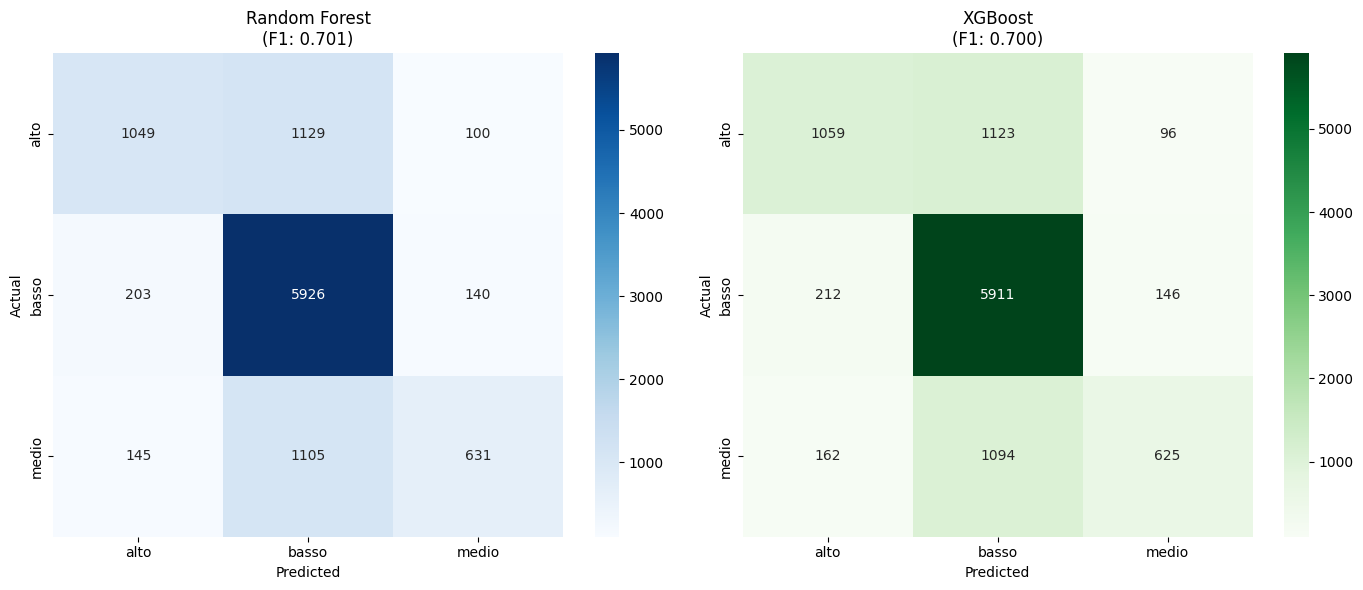


✓ Modelli ottimizzati e pronti per SHAP!


In [7]:
# =============================================================================
# CLASSIFICAZIONE CON GRID SEARCH CV - RANDOM FOREST & XGBOOST
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. CREAZIONE TARGET CATEGORICO
# =============================================================================

df_model = df_merged.copy()

print("Distribuzione score_comment:")
print(df_model['score_comment'].describe())

print(f"\nSoglie definite:")
print(f"  Basso: score 0-3")
print(f"  Medio: score 4-10")
print(f"  Alto:  score 11+")

def categorize_score(score):
    if score <= 3:
        return 'basso'
    elif score <= 10:
        return 'medio'
    else:
        return 'alto'

df_model['score_category'] = df_model['score_comment'].apply(categorize_score)
print("\nDistribuzione categorie:")
print(df_model['score_category'].value_counts())

# =============================================================================
# 2. PREPARAZIONE FEATURE
# =============================================================================

num_features = [
    'score_post', 'UpVote_Ratio', 'Num_Comments', 
    'body_len', 'word_count', 'avg_word_count', 
    'emotion_score', 'ora'
]

cat_features = [
    'macro_topic', 'Sentiment', 'giorno_settimana', 
    'emotion', 'topic_label', 'sentiment_cat', 'mese'
]

for col in num_features:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

label_encoders = {}
for col in cat_features:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna('Unknown')
        le = LabelEncoder()
        df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

target_encoder = LabelEncoder()
df_model['score_category_encoded'] = target_encoder.fit_transform(df_model['score_category'])

feature_cols = num_features.copy()
for col in cat_features:
    if col in df_model.columns:
        feature_cols.append(col + '_encoded')
feature_cols = [f for f in feature_cols if f in df_model.columns]

X = df_model[feature_cols]
y = df_model['score_category_encoded']

mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

print(f"\nDataset: {X.shape[0]} righe, {X.shape[1]} feature")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =============================================================================
# 3. RANDOM FOREST CON GRID SEARCH
# =============================================================================

print("\n" + "="*60)
print("RANDOM FOREST - GRID SEARCH CV")
print("="*60)

# Definisci griglia parametri
param_grid_rf = {
    'n_estimators': [200, 250, 300],
    'max_depth': [20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

print("\nParametri da testare:")
for param, values in param_grid_rf.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid_rf.values()])
print(f"\nTotale combinazioni: {total_combinations}")
print("Inizio Grid Search (può richiedere qualche minuto)...\n")

# Grid Search con 5-fold CV
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

# Miglior modello
rf_model = grid_rf.best_estimator_
print("\n✓ Grid Search completata!")
print(f"\nMigliori parametri Random Forest:")
for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")

# Valutazione
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nPerformance Random Forest (test set):")
print(f"  Best CV Score: {grid_rf.best_score_:.4f}")
print(f"  Test Accuracy: {rf_accuracy:.4f}")
print(f"  Test F1-Score: {rf_f1:.4f}")

# Top 5 configurazioni
print("\nTop 5 configurazioni:")
results_rf = pd.DataFrame(grid_rf.cv_results_)
top_5_rf = results_rf.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
for idx, row in top_5_rf.iterrows():
    print(f"\n  Rank {int(row['rank_test_score'])}:")
    print(f"    Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"    Params: {row['params']}")

# =============================================================================
# 4. XGBOOST CON GRID SEARCH
# =============================================================================

print("\n" + "="*60)
print("XGBOOST - GRID SEARCH CV")
print("="*60)

# Griglia parametri
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, 15],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

print("\nParametri da testare:")
for param, values in param_grid_xgb.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid_xgb.values()])
print(f"\nTotale combinazioni: {total_combinations}")
print("Inizio Grid Search (può richiedere qualche minuto)...\n")

# Grid Search
xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

grid_xgb = GridSearchCV(
    xgb_base,
    param_grid_xgb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

# Miglior modello
xgb_model = grid_xgb.best_estimator_
print("\n✓ Grid Search completata!")
print(f"\nMigliori parametri XGBoost:")
for param, value in grid_xgb.best_params_.items():
    print(f"  {param}: {value}")

# Valutazione
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\nPerformance XGBoost (test set):")
print(f"  Best CV Score: {grid_xgb.best_score_:.4f}")
print(f"  Test Accuracy: {xgb_accuracy:.4f}")
print(f"  Test F1-Score: {xgb_f1:.4f}")

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))

# Top 5 configurazioni
print("\nTop 5 configurazioni:")
results_xgb = pd.DataFrame(grid_xgb.cv_results_)
top_5_xgb = results_xgb.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
for idx, row in top_5_xgb.iterrows():
    print(f"\n  Rank {int(row['rank_test_score'])}:")
    print(f"    Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"    Params: {row['params']}")

# =============================================================================
# 5. CONFRONTO FINALE
# =============================================================================

print("\n" + "="*60)
print("CONFRONTO MODELLI OTTIMIZZATI")
print("="*60)

comparison = pd.DataFrame({
    'Modello': ['Random Forest', 'XGBoost'],
    'CV Score': [grid_rf.best_score_, grid_xgb.best_score_],
    'Test Accuracy': [rf_accuracy, xgb_accuracy],
    'Test F1-Score': [rf_f1, xgb_f1]
})
print("\n" + comparison.to_string(index=False))

# Identifica migliore
best_model = xgb_model if xgb_f1 > rf_f1 else rf_model
best_name = 'XGBoost' if xgb_f1 > rf_f1 else 'Random Forest'
best_pred = y_pred_xgb if xgb_f1 > rf_f1 else y_pred_rf

print(f"\n✓ Modello migliore: {best_name}")
print(f"  Improvement over baseline: +{max(xgb_f1, rf_f1) - 0.33:.1%}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RF Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Random Forest\n(F1: {rf_f1:.3f})')

# XGB Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'XGBoost\n(F1: {xgb_f1:.3f})')

plt.tight_layout()
plt.show()

# =============================================================================
# 6. SALVA OGGETTI PER SHAP
# =============================================================================

models = {
    'random_forest': rf_model,
    'xgboost': xgb_model,
    'best_model': best_model,
    'best_name': best_name
}

shap_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'feature_cols': feature_cols,
    'target_encoder': target_encoder
}

print("\n✓ Modelli ottimizzati e pronti per SHAP!")

ANALISI SHAP - MODELLO VINCENTE
Modello: Random Forest
Parametri ottimali: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Campione: 500 osservazioni
Calcolo SHAP values (può richiedere 1-2 minuti)...
Tipo shap_values: <class 'numpy.ndarray'>
Shape: (500, 11, 3)
Conversione array 3D in lista...
Lista di 3 array, shape: (500, 11)
✓ SHAP values calcolati!

1. BAR PLOT - IMPORTANZA GLOBALE


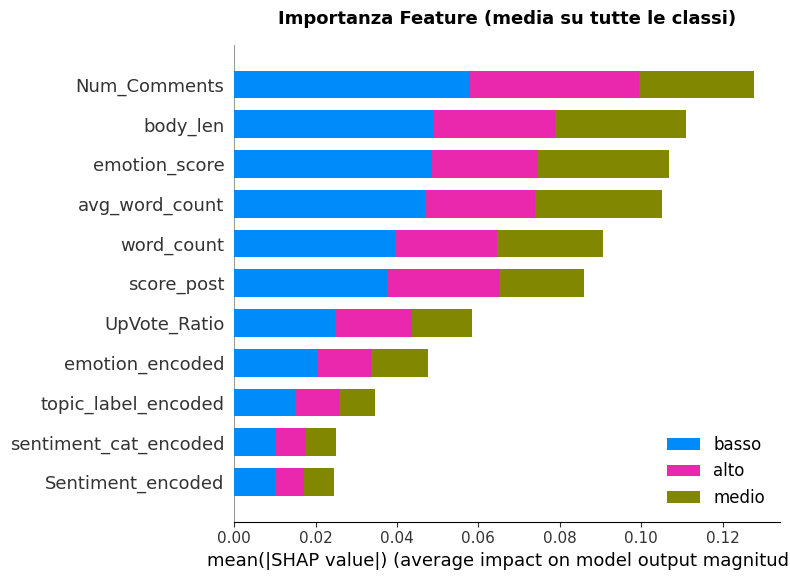


2. BEESWARM PLOT - CLASSE 'ALTO'


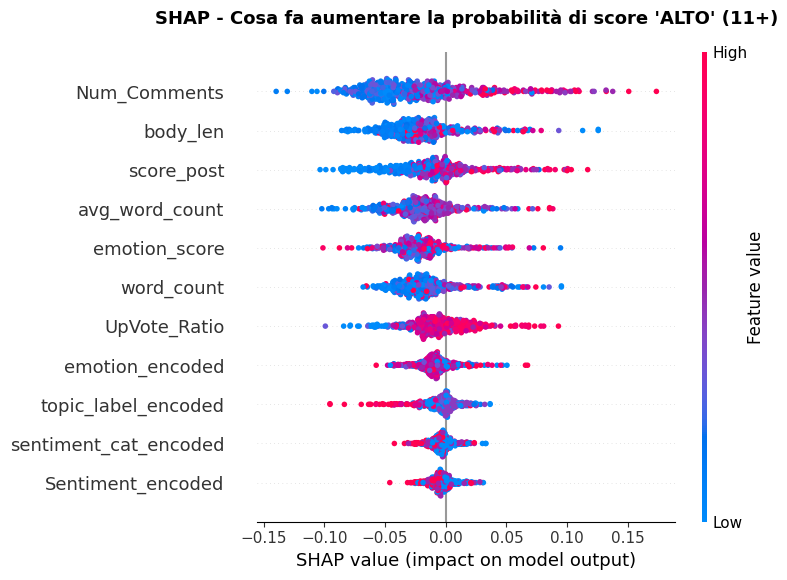


3. BEESWARM PLOT - CLASSE 'BASSO'


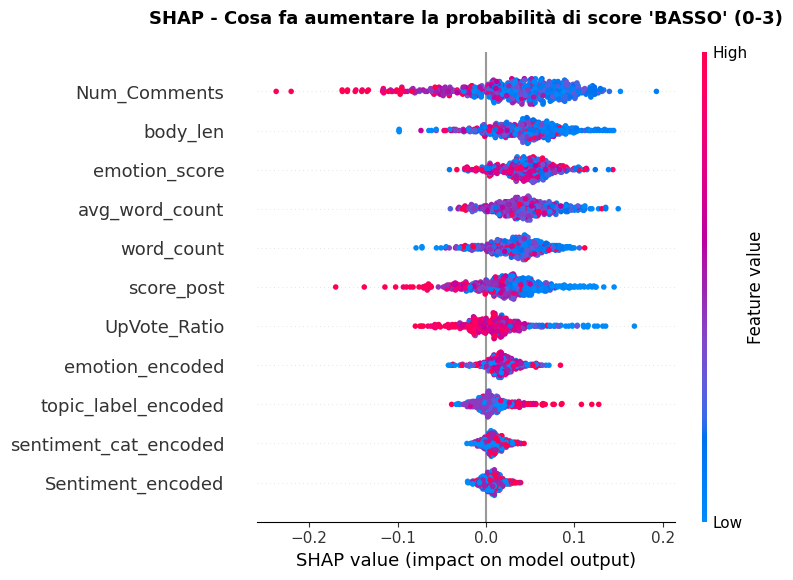


4. BEESWARM PLOT - CLASSE 'MEDIO'


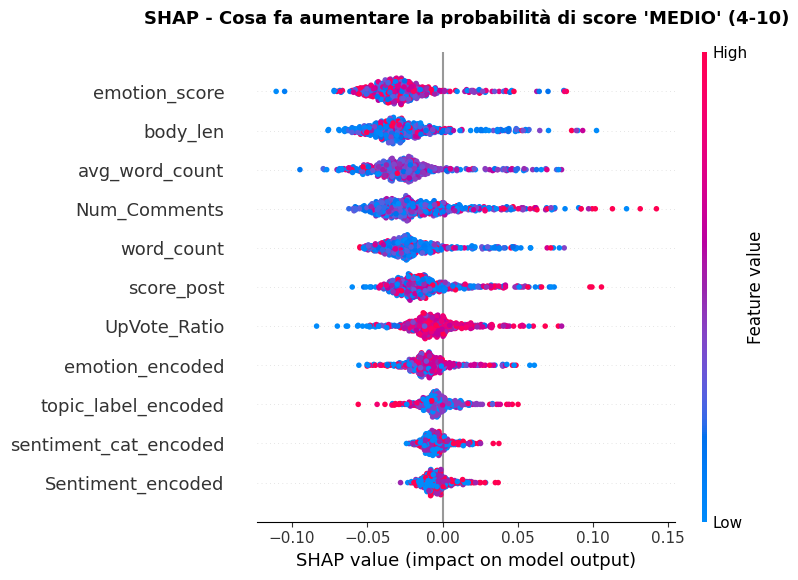


6. WATERFALL PLOTS - ESEMPI PER OGNI CLASSE

>> Esempio classe 'ALTO'
   Predizione: alto
   Classe reale: alto


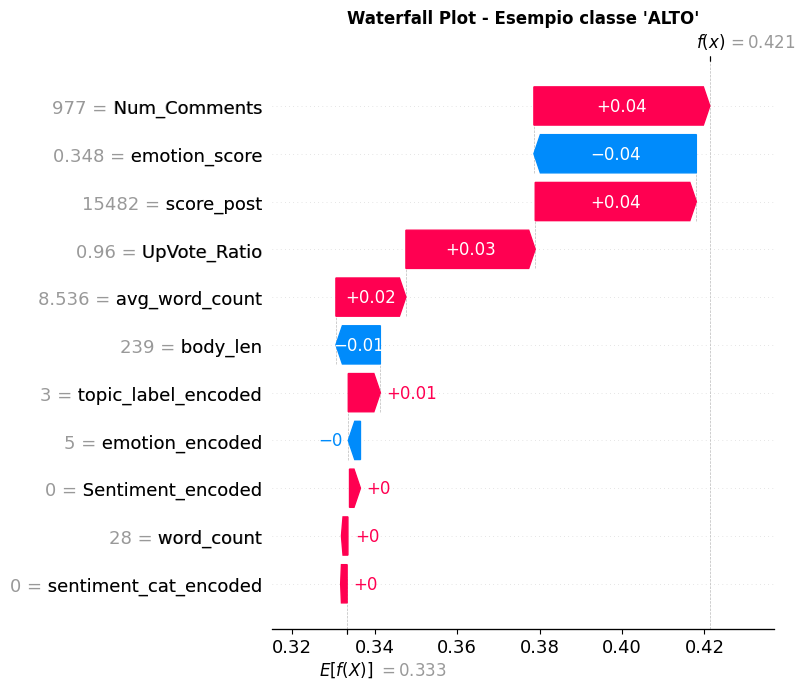


>> Esempio classe 'BASSO'
   Predizione: basso
   Classe reale: basso


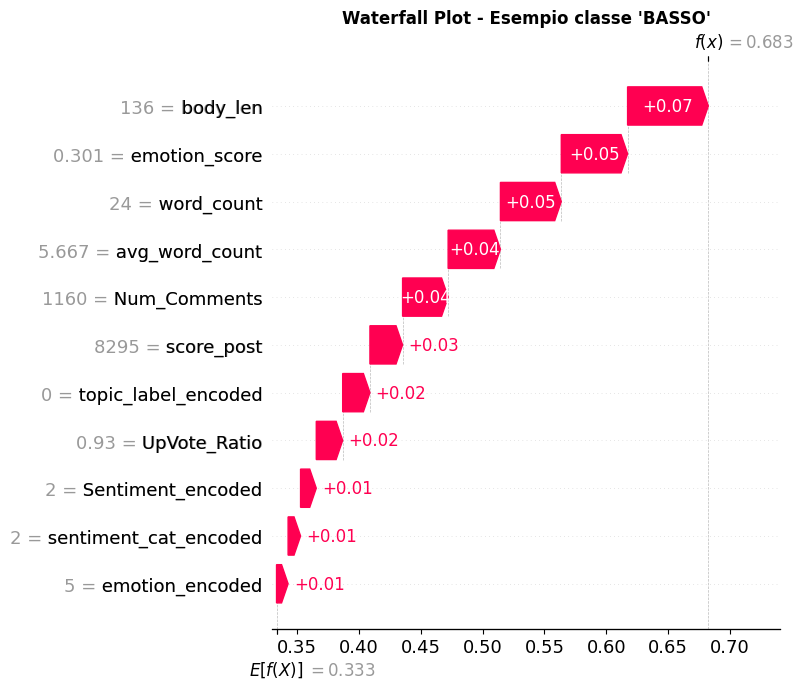


>> Esempio classe 'MEDIO'
   Predizione: medio
   Classe reale: medio


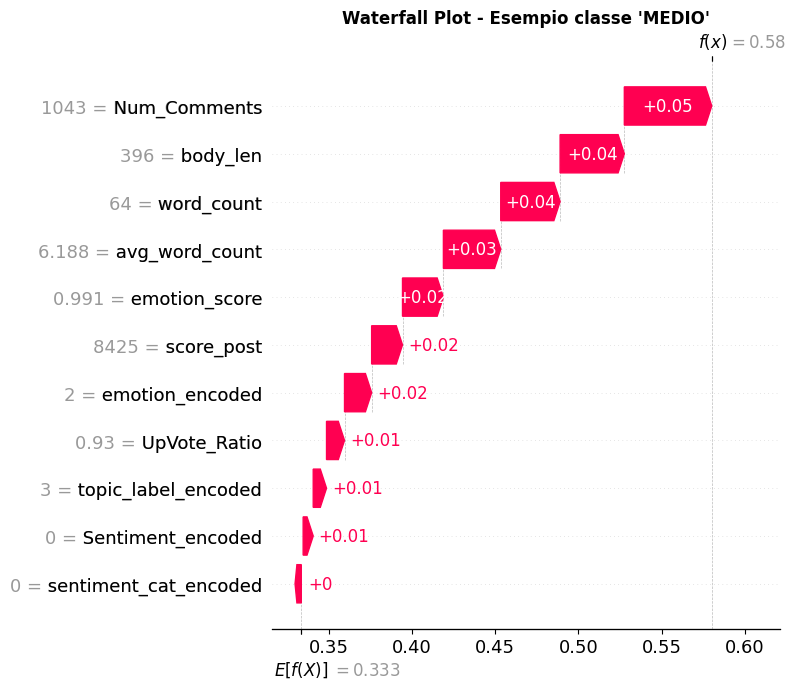


8. RIEPILOGO IMPORTANZA SHAP

Top 15 Feature per importanza SHAP:
              feature  shap_mean  shap_alto  shap_basso  shap_medio
         Num_Comments   0.042568   0.041646    0.057820    0.028239
             body_len   0.037014   0.029760    0.049073    0.032209
        emotion_score   0.035598   0.025968    0.048551    0.032275
       avg_word_count   0.035053   0.027157    0.046833    0.031168
           word_count   0.030237   0.024938    0.039585    0.026188
           score_post   0.028639   0.027644    0.037523    0.020752
         UpVote_Ratio   0.019468   0.018884    0.024872    0.014647
      emotion_encoded   0.015898   0.013263    0.020404    0.014028
  topic_label_encoded   0.011563   0.010867    0.014819    0.009003
sentiment_cat_encoded   0.008373   0.007333    0.010285    0.007500
    Sentiment_encoded   0.008179   0.007267    0.009945    0.007324

✓ Salvato: shap_importance_random_forest.csv

9. CONFRONTO SHAP vs RANDOM FOREST FEATURE IMPORTANCE

Top 15 Feature 

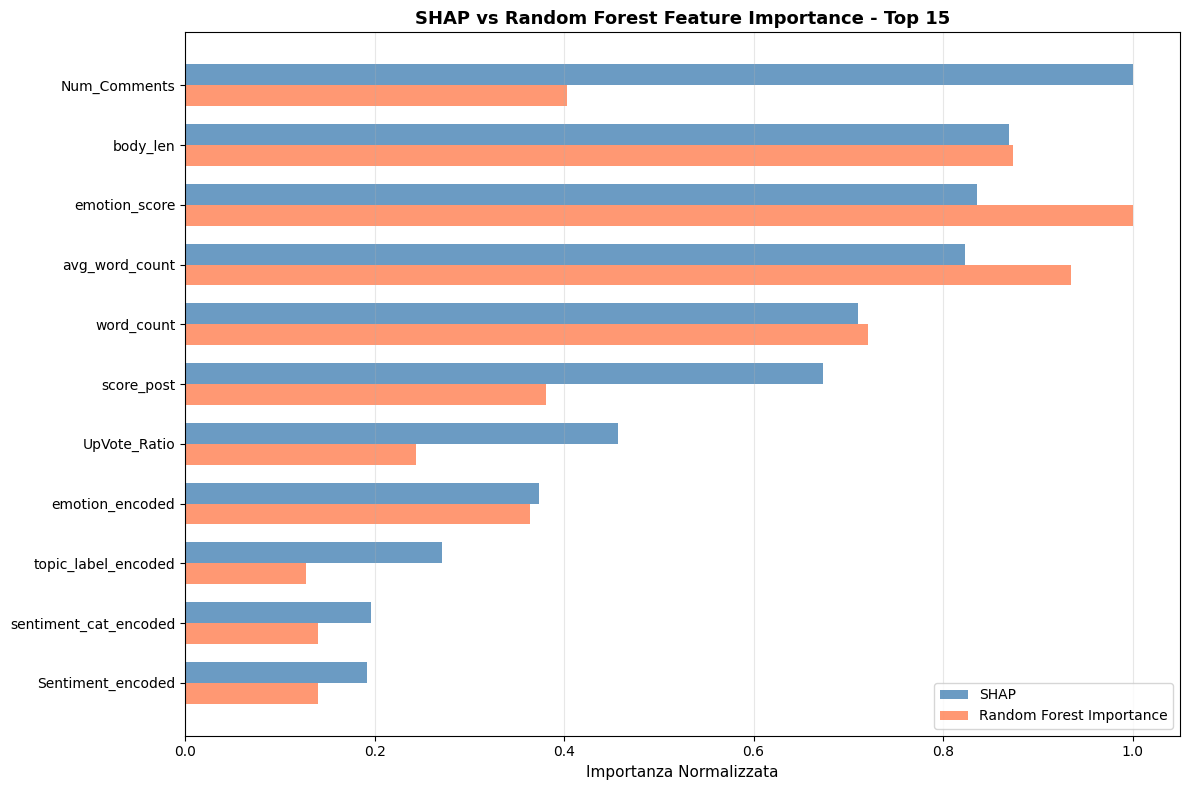


✓ ANALISI SHAP COMPLETATA!

MODELLO FINALE:
  Algoritmo: Random Forest
  Accuracy: 72.94%
  F1-Score: 70.12%
  Miglioramento vs random: +37.1%

TOP 3 FEATURE PIÙ IMPORTANTI (SHAP):
  Num_Comments: 0.0426
  body_len: 0.0370
  emotion_score: 0.0356

INTERPRETAZIONE BEESWARM PLOT:
  • Colore ROSSO = valore alto della feature
  • Colore BLU = valore basso della feature
  • Asse X positivo = aumenta probabilità classe
  • Asse X negativo = diminuisce probabilità classe


In [9]:
# =============================================================================
# ANALISI SHAP - MODELLO VINCENTE (RANDOM FOREST O XGBOOST)
# =============================================================================

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("="*60)
print("ANALISI SHAP - MODELLO VINCENTE")
print("="*60)
print(f"Modello: {best_name}")

# Mostra parametri ottimali
if best_name == 'Random Forest':
    print(f"Parametri ottimali: {rf_model.get_params()}\n")
else:
    print(f"Parametri ottimali: {xgb_model.get_params()}\n")

# Campione per SHAP (500 è un buon compromesso)
sample_size = min(500, len(X_test))
# Salva gli indici prima del reset
sample_indices = X_test.sample(n=sample_size, random_state=42).index
X_sample = X_test.loc[sample_indices].reset_index(drop=True)
y_sample = y_test.loc[sample_indices].reset_index(drop=True)

print(f"Campione: {len(X_sample)} osservazioni")

# Calcola SHAP values
print("Calcolo SHAP values (può richiedere 1-2 minuti)...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Converti in array numpy
X_sample_array = X_sample.values

print(f"Tipo shap_values: {type(shap_values)}")
if isinstance(shap_values, np.ndarray):
    print(f"Shape: {shap_values.shape}")

# Converti array 3D in lista se necessario
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print(f"Conversione array 3D in lista...")
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    print(f"Lista di {len(shap_values)} array, shape: {shap_values[0].shape}")
elif isinstance(shap_values, list):
    print(f"Lista di {len(shap_values)} array, shape: {shap_values[0].shape}")

print("✓ SHAP values calcolati!\n")

# =============================================================================
# 1. BAR PLOT - IMPORTANZA GLOBALE
# =============================================================================

print("="*60)
print("1. BAR PLOT - IMPORTANZA GLOBALE")
print("="*60)

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_sample_array, 
                  feature_names=feature_cols,
                  class_names=target_encoder.classes_,
                  plot_type="bar", show=False)
plt.title("Importanza Feature (media su tutte le classi)", 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# =============================================================================
# 2. BEESWARM PLOT - CLASSE "ALTO"
# =============================================================================

print("\n" + "="*60)
print("2. BEESWARM PLOT - CLASSE 'ALTO'")
print("="*60)

alto_idx = list(target_encoder.classes_).index('alto')

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[alto_idx], X_sample_array, 
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP - Cosa fa aumentare la probabilità di score 'ALTO' (11+)", 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. BEESWARM PLOT - CLASSE "BASSO"
# =============================================================================

print("\n" + "="*60)
print("3. BEESWARM PLOT - CLASSE 'BASSO'")
print("="*60)

basso_idx = list(target_encoder.classes_).index('basso')

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[basso_idx], X_sample_array, 
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP - Cosa fa aumentare la probabilità di score 'BASSO' (0-3)", 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. BEESWARM PLOT - CLASSE "MEDIO"
# =============================================================================

print("\n" + "="*60)
print("4. BEESWARM PLOT - CLASSE 'MEDIO'")
print("="*60)

medio_idx = list(target_encoder.classes_).index('medio')

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[medio_idx], X_sample_array, 
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP - Cosa fa aumentare la probabilità di score 'MEDIO' (4-10)", 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# =============================================================================
# 6. WATERFALL PLOTS - ESEMPI
# =============================================================================

print("\n" + "="*60)
print("6. WATERFALL PLOTS - ESEMPI PER OGNI CLASSE")
print("="*60)

predictions = best_model.predict(X_sample)

for class_idx, class_name in enumerate(target_encoder.classes_):
    examples_idx = np.where(predictions == class_idx)[0]
    
    if len(examples_idx) > 0:
        sample_idx = examples_idx[0]
        
        print(f"\n>> Esempio classe '{class_name.upper()}'")
        print(f"   Predizione: {class_name}")
        print(f"   Classe reale: {target_encoder.classes_[y_sample.iloc[sample_idx]]}")
        
        explanation = shap.Explanation(
            values=shap_values[class_idx][sample_idx],
            base_values=explainer.expected_value[class_idx],
            data=X_sample_array[sample_idx],
            feature_names=feature_cols
        )
        
        plt.figure(figsize=(12, 7))
        shap.plots.waterfall(explanation, max_display=15, show=False)
        plt.title(f"Waterfall Plot - Esempio classe '{class_name.upper()}'", 
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


# =============================================================================
# 8. TABELLA IMPORTANZA SHAP
# =============================================================================

print("\n" + "="*60)
print("8. RIEPILOGO IMPORTANZA SHAP")
print("="*60)

importance_df = pd.DataFrame({'feature': feature_cols})

for class_idx, class_name in enumerate(target_encoder.classes_):
    importance_df[f'shap_{class_name}'] = np.abs(shap_values[class_idx]).mean(axis=0)

shap_cols = [f'shap_{c}' for c in target_encoder.classes_]
importance_df['shap_mean'] = importance_df[shap_cols].mean(axis=1)
importance_df = importance_df.sort_values('shap_mean', ascending=False)

print("\nTop 15 Feature per importanza SHAP:")
print(importance_df[['feature', 'shap_mean'] + shap_cols].head(15).to_string(index=False))

# Salva per analisi successive
csv_filename = f'shap_importance_{best_name.lower().replace(" ", "_")}.csv'
importance_df.to_csv(csv_filename, index=False)
print(f"\n✓ Salvato: {csv_filename}")

# =============================================================================
# 9. CONFRONTO SHAP vs FEATURE IMPORTANCE DEL MODELLO
# =============================================================================

print("\n" + "="*60)
print(f"9. CONFRONTO SHAP vs {best_name.upper()} FEATURE IMPORTANCE")
print("="*60)

model_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'model_importance': best_model.feature_importances_
})

comparison_df = importance_df[['feature', 'shap_mean']].merge(model_importance_df, on='feature')
comparison_df['shap_rank'] = comparison_df['shap_mean'].rank(ascending=False)
comparison_df['model_rank'] = comparison_df['model_importance'].rank(ascending=False)
comparison_df['rank_diff'] = abs(comparison_df['shap_rank'] - comparison_df['model_rank'])
comparison_df = comparison_df.sort_values('shap_mean', ascending=False)

print("\nTop 15 Feature - Confronto ranking:")
print(comparison_df[['feature', 'shap_mean', 'model_importance', 
                     'shap_rank', 'model_rank', 'rank_diff']].head(15).to_string(index=False))

# Grafico confronto
fig, ax = plt.subplots(figsize=(12, 8))
top_n = 15
top_features = comparison_df.head(top_n)

x = np.arange(len(top_features))
width = 0.35

shap_norm = top_features['shap_mean'] / top_features['shap_mean'].max()
model_norm = top_features['model_importance'] / top_features['model_importance'].max()

ax.barh(x - width/2, shap_norm, width, label='SHAP', alpha=0.8, color='steelblue')
ax.barh(x + width/2, model_norm, width, label=f'{best_name} Importance', alpha=0.8, color='coral')

ax.set_yticks(x)
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importanza Normalizzata', fontsize=11)
ax.set_title(f'SHAP vs {best_name} Feature Importance - Top {top_n}', 
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# CONCLUSIONI
# =============================================================================

print("\n" + "="*60)
print("✓ ANALISI SHAP COMPLETATA!")
print("="*60)

# Ottieni le metriche corrette in base al modello vincente
if best_name == 'Random Forest':
    final_accuracy = rf_accuracy
    final_f1 = rf_f1
else:
    final_accuracy = xgb_accuracy
    final_f1 = xgb_f1

print("\nMODELLO FINALE:")
print(f"  Algoritmo: {best_name}")
print(f"  Accuracy: {final_accuracy:.2%}")
print(f"  F1-Score: {final_f1:.2%}")
print(f"  Miglioramento vs random: +{(final_f1 - 0.33)*100:.1f}%")

print("\nTOP 3 FEATURE PIÙ IMPORTANTI (SHAP):")
for i, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']}: {row['shap_mean']:.4f}")

print("\nINTERPRETAZIONE BEESWARM PLOT:")
print("  • Colore ROSSO = valore alto della feature")
print("  • Colore BLU = valore basso della feature")
print("  • Asse X positivo = aumenta probabilità classe")
print("  • Asse X negativo = diminuisce probabilità classe")